# 23 — Gateway IG Validation — BPIC17

Companion to notebook 22 (Gateway Decision Analysis). For each gateway, runs
Integrated Gradients on prefixes that end there and compares the IG feature
ranking to the surrogate tree's Gini importance.

- **IG vs Surrogate**: validates whether the surrogate explains the right features
- **IG vs Ground Truth**: checks if the model attends to features that actually
  drive real-world decisions
- **Correct vs Incorrect**: reveals which features the model overweights when
  it makes mistakes at gateways

In [1]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))

src_path = str(_current / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

In [2]:
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.stats import spearmanr

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# --- Load dataset ---
data_path = _current / 'encoded_data' / 'BPIC_2017_all_5_test.pkl'
dataset = torch.load(data_path, weights_only=False)

sample = dataset[0]
n_cat = len(sample[0])
n_num = len(sample[1])
seq_len = sample[0][0].shape[0]

# --- Load model ---
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM

model_path = (_current / 'src' / 'notebooks' / 'training_variational_dropout'
              / 'BPIC17' / 'BPIC_2017_full_grad_norm_new_4layer.pkl')
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(model_path), dropout=0.0)
model.eval()

# --- TensorDecoder + activity vocab ---
from src.interpretability.utils.tensor_decoder import TensorDecoder

decoder = TensorDecoder(dataset)

ACTIVITY_FEATURE = 'concept:name'
activity_idx_to_label = decoder.idx_to_label[ACTIVITY_FEATURE]
max_idx = max(activity_idx_to_label.keys())
activity_names = [activity_idx_to_label.get(i, f'<unk_{i}>') for i in range(max_idx + 1)]
eos_idx = next(i for i, name in enumerate(activity_names) if name == 'EOS')

# --- Predictor ---
from src.interpretability.perturbation_methods.revised_plus.revised_plus import RevisedPlusModelPredictor

predictor = RevisedPlusModelPredictor(model, suffix_step=0, activity_feature=ACTIVITY_FEATURE)

# --- InterpretabilityTool ---
from src.interpretability import InterpretabilityTool

tool = InterpretabilityTool(model, model.data_set_categories, device=torch.device('cpu'))

# Feature indices (BPIC17)
ACT_IDX = decoder.cat_features.index('concept:name')       # 0
RES_IDX = decoder.cat_features.index('org:resource')        # 2
LC_IDX = decoder.cat_features.index('lifecycle:transition')  # 4
LG_IDX = decoder.cat_features.index('case:LoanGoal')        # 5
AT_IDX = decoder.cat_features.index('case:ApplicationType')  # 6

elapsed_num_idx = decoder.num_features.index('case_elapsed_time')
event_num_idx = decoder.num_features.index('event_elapsed_time')
amount_num_idx = decoder.num_features.index('case:RequestedAmount')
credit_num_idx = decoder.num_features.index('CreditScore')
day_num_idx = decoder.num_features.index('day_in_week')

# All model input features (what IG sees)
cat_categories, num_categories = model.data_set_categories
ALL_CAT_FEATURES = [name for name, _, _ in cat_categories]
ALL_NUM_FEATURES = [name for name, _, _ in num_categories]
ALL_FEATURES = ALL_CAT_FEATURES + ALL_NUM_FEATURES

print(f'Dataset: {len(dataset)} sequences, seq_len={seq_len}')
print(f'Act={ACT_IDX}, Res={RES_IDX}, LC={LC_IDX}, LG={LG_IDX}, AT={AT_IDX}')
print(f'elapsed={elapsed_num_idx}, event={event_num_idx}, amount={amount_num_idx}, '
      f'credit={credit_num_idx}, day={day_num_idx}')
print(f'Model input features ({len(ALL_FEATURES)}): {ALL_FEATURES}')

Data set categories:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('Action', 7, {'Created': 1, 'Deleted': 2, 'EOS': 3, 'Obtained': 4, 'Released': 5, 'statechange': 6}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 8, 'User_105': 9, 'User_106': 10, 'User_107': 11, 'User_108': 12, 'User_109': 13, 'User_11': 14, 'User_110': 15, 'U

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:163: DeprecationWarning: module 'sre_parse' is deprecated
  import sre_parse
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:164: DeprecationWarning: module 'sre_constants' is deprecated
  import sre_constants


Dataset: 253196 sequences, seq_len=96
Act=0, Res=2, LC=4, LG=5, AT=6
elapsed=0, event=1, amount=4, credit=8, day=2
Model input features (18): ['concept:name', 'Action', 'org:resource', 'EventOrigin', 'lifecycle:transition', 'case:LoanGoal', 'case:ApplicationType', 'Accepted', 'Selected', 'case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day', 'case:RequestedAmount', 'FirstWithdrawalAmount', 'NumberOfTerms', 'MonthlyCost', 'CreditScore']


## Identify gateways and collect prefixes

Reproduces the gateway detection and prefix collection from notebook 22.
Also trains surrogate trees so we can compare Gini importances to IG.

In [3]:
MIN_CASES = 50
MIN_BRANCH = 10
MIN_SAMPLES_LEAF = 20
IG_STEPS = 30
MAX_SAMPLES_PER_GATEWAY = 100  # cap IG computation per gateway

# --- Unique cases ---
cases = {}
for i in range(len(dataset)):
    cat_t, num_t, case_id = dataset[i]
    trace_len = int((cat_t[0] != 0).sum().item())
    if case_id not in cases or trace_len > cases[case_id][1]:
        cases[case_id] = (i, trace_len)

# --- DFG & decision points ---
dfg = {}
for case_id, (ds_idx, trace_len) in cases.items():
    cat_full = dataset[ds_idx][0]
    src_start = seq_len - trace_len
    acts = cat_full[ACT_IDX][src_start:src_start + trace_len]

    useful_len = trace_len
    for j in range(trace_len - 1, -1, -1):
        if acts[j].item() == eos_idx:
            useful_len = j
        else:
            break

    act_names = [activity_names[acts[j].item()] for j in range(useful_len)]
    for k in range(len(act_names) - 1):
        edge = (act_names[k], act_names[k + 1])
        dfg[edge] = dfg.get(edge, 0) + 1

successors_map = {}
for (src, tgt), count in dfg.items():
    successors_map.setdefault(src, {})[tgt] = count

decision_points = {
    act: succs for act, succs in successors_map.items()
    if len(succs) > 1
}

print(f'Found {len(decision_points)} decision points (activities with >1 successor)')

# --- Collect per-gateway prefix data ---
def extract_features(cat_tuple, num_tuple, decoder):
    """Extract engineered aggregate features from a single BPIC17 prefix."""
    act_tensor = cat_tuple[ACT_IDX]
    mask = act_tensor != 0
    prefix_len = int(mask.sum().item())
    if prefix_len == 0:
        return None
    nonzero = mask.nonzero(as_tuple=True)[0]
    start = nonzero[0].item()
    end = start + prefix_len
    acts = act_tensor[start:end]

    last_act = acts[-1].item()
    repeated = 1
    for k in range(len(acts) - 2, -1, -1):
        if acts[k].item() == last_act:
            repeated += 1
        else:
            break

    # Time features (inverse-transformed)
    total_elapsed = decoder.decode_numerical_value(
        'case_elapsed_time', num_tuple[elapsed_num_idx][end - 1].item())
    last_event_dur = decoder.decode_numerical_value(
        'event_elapsed_time', num_tuple[event_num_idx][end - 1].item())
    event_durs = [decoder.decode_numerical_value(
        'event_elapsed_time', num_tuple[event_num_idx][j].item())
        for j in range(start, end)]
    mean_event_dur = float(np.mean(event_durs))

    # Resource features
    res_tensor = cat_tuple[RES_IDX]
    resources = res_tensor[start:end].tolist()
    n_unique_res = len(set(resources))

    # BPIC17-specific numerical features
    requested_amount = decoder.decode_numerical_value(
        'case:RequestedAmount', num_tuple[amount_num_idx][end - 1].item())
    credit_score = decoder.decode_numerical_value(
        'CreditScore', num_tuple[credit_num_idx][end - 1].item())
    day_in_week = decoder.decode_numerical_value(
        'day_in_week', num_tuple[day_num_idx][end - 1].item())

    return {
        'prefix_length': prefix_len,
        'last_activity': decoder.decode_categorical_value(ACT_IDX, acts[-1].item()),
        'first_activity': decoder.decode_categorical_value(ACT_IDX, acts[0].item()),
        'n_unique_activities': len(set(acts.tolist())),
        'last_activity_repeated': repeated,
        'total_elapsed_time': total_elapsed,
        'last_event_duration': last_event_dur,
        'mean_event_duration': mean_event_dur,
        'last_resource': decoder.decode_categorical_value(RES_IDX, res_tensor[end - 1].item()),
        'n_unique_resources': n_unique_res,
        'loan_goal': decoder.decode_categorical_value(LG_IDX, cat_tuple[LG_IDX][end - 1].item()),
        'application_type': decoder.decode_categorical_value(AT_IDX, cat_tuple[AT_IDX][end - 1].item()),
        'requested_amount': requested_amount,
        'credit_score': credit_score,
        'last_lifecycle': decoder.decode_categorical_value(LC_IDX, cat_tuple[LC_IDX][end - 1].item()),
        'day_in_week': day_in_week,
    }


gateway_data = {}
skipped_reasons = []

for gateway_act, succs in decision_points.items():
    qualifying_branches = [s for s, c in succs.items() if c >= MIN_BRANCH]
    total_count = sum(succs.values())
    if len(qualifying_branches) < 2 or total_count < MIN_CASES:
        reason = []
        if len(qualifying_branches) < 2:
            branch_counts = {s: c for s, c in succs.items()}
            reason.append(f'only {len(qualifying_branches)} branches with >={MIN_BRANCH} cases (branches: {branch_counts})')
        if total_count < MIN_CASES:
            reason.append(f'only {total_count} total cases (need {MIN_CASES})')
        skipped_reasons.append((gateway_act, '; '.join(reason)))
        continue

    feature_rows, actual_labels, cat_list, num_list = [], [], [], []
    # Also store full tensors for IG
    full_cat_list, full_num_list, prefix_len_list = [], [], []

    for case_id, (ds_idx, trace_len) in cases.items():
        cat_full, num_full, _ = dataset[ds_idx]
        src_start = seq_len - trace_len
        acts = cat_full[ACT_IDX][src_start:src_start + trace_len]

        useful_len = trace_len
        for j in range(trace_len - 1, -1, -1):
            if acts[j].item() == eos_idx:
                useful_len = j
            else:
                break

        for k in range(useful_len - 1):
            if activity_names[acts[k].item()] != gateway_act:
                continue
            next_act_name = activity_names[acts[k + 1].item()]
            prefix_len = k + 1
            pad_len = seq_len - prefix_len

            cat_prefix = []
            for c in cat_full:
                t = torch.zeros_like(c)
                t[pad_len:] = c[src_start:src_start + prefix_len]
                cat_prefix.append(t)
            num_prefix = []
            for n in num_full:
                t = torch.zeros_like(n)
                t[pad_len:] = n[src_start:src_start + prefix_len]
                num_prefix.append(t)

            feats = extract_features(tuple(cat_prefix), tuple(num_prefix), decoder)
            if feats is not None:
                feature_rows.append(feats)
                actual_labels.append(next_act_name)
                cat_list.append(cat_prefix)
                num_list.append(num_prefix)
                full_cat_list.append(cat_full)
                full_num_list.append(num_full)
                prefix_len_list.append(prefix_len)

    if len(feature_rows) < MIN_CASES:
        skipped_reasons.append((gateway_act, f'only {len(feature_rows)} collected prefixes (need {MIN_CASES})'))
        continue

    X = pd.DataFrame(feature_rows)
    y_actual = np.array(actual_labels)

    N = len(X)
    cat_batch = [torch.stack([cat_list[i][ci] for i in range(N)]) for ci in range(n_cat)]
    num_stacked = torch.stack([torch.stack(num_list[i], dim=-1) for i in range(N)])
    preds, probs = predictor.predict_batch(cat_batch, num_stacked, batch_size=128)
    y_lstm = np.array([activity_names[p] for p in preds])

    gateway_data[gateway_act] = {
        'X': X, 'y_lstm': y_lstm, 'y_actual': y_actual,
        'successors': succs,
        'full_cat_list': full_cat_list,
        'full_num_list': full_num_list,
        'prefix_len_list': prefix_len_list,
    }

    lstm_acc = (y_lstm == y_actual).mean()
    print(f'{gateway_act}: {N} prefixes, LSTM accuracy={lstm_acc:.3f}')

print(f'\n{len(gateway_data)} qualifying gateways')

if skipped_reasons:
    print(f'\nSkipped {len(skipped_reasons)} decision points:')
    for act, reason in skipped_reasons:
        print(f'  {act}: {reason}')

if len(gateway_data) == 0:
    print('\n⚠ WARNING: No gateways qualified! All downstream cells will produce empty output.')
    print('Consider lowering MIN_CASES or MIN_BRANCH thresholds above.')

Found 22 decision points (activities with >1 successor)
A_Create Application: 6301 prefixes, LSTM accuracy=0.236
W_Handle leads: 9382 prefixes, LSTM accuracy=0.868
W_Complete application: 29857 prefixes, LSTM accuracy=0.721
A_Concept: 6301 prefixes, LSTM accuracy=0.704
A_Accepted: 6300 prefixes, LSTM accuracy=0.941
O_Created: 8648 prefixes, LSTM accuracy=0.806
O_Sent (mail and online): 7975 prefixes, LSTM accuracy=0.866
W_Call after offers: 36452 prefixes, LSTM accuracy=0.905
A_Complete: 6270 prefixes, LSTM accuracy=0.966
A_Cancelled: 2115 prefixes, LSTM accuracy=0.820
O_Cancelled: 3341 prefixes, LSTM accuracy=0.625
W_Validate application: 39038 prefixes, LSTM accuracy=0.781
A_Validating: 7650 prefixes, LSTM accuracy=0.603
O_Returned: 4613 prefixes, LSTM accuracy=0.892
O_Refused: 946 prefixes, LSTM accuracy=0.514
W_Call incomplete files: 32395 prefixes, LSTM accuracy=0.910
A_Incomplete: 4511 prefixes, LSTM accuracy=0.967
O_Sent (online only): 416 prefixes, LSTM accuracy=0.558
A_Pending

## Train surrogate trees (same as notebook 22)

In [4]:
def select_best_depth(X_train, y_train, X_test, y_test, depths=(3, 4, 5, 6, 8, None)):
    results = []
    for depth in depths:
        clf = DecisionTreeClassifier(
            max_depth=depth, min_samples_leaf=MIN_SAMPLES_LEAF,
            class_weight='balanced', random_state=42)
        clf.fit(X_train, y_train)
        results.append({'depth': depth, 'test': clf.score(X_test, y_test), 'clf': clf})
    best_idx = 0
    best_test = results[0]['test']
    for i in range(1, len(results)):
        if results[i]['test'] > best_test + 0.02:
            best_idx = i
            best_test = results[i]['test']
    return results[best_idx]['clf']


gateway_results = {}

for gateway_act, gd in gateway_data.items():
    X = gd['X']
    y_lstm = gd['y_lstm']
    y_actual = gd['y_actual']

    cat_cols = [c for c in X.columns if X[c].dtype == 'object']
    ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_enc = X.copy()
    X_enc[cat_cols] = ord_enc.fit_transform(X[cat_cols].astype(str))

    cat_mappings = {}
    for i, col in enumerate(cat_cols):
        cat_mappings[col] = list(ord_enc.categories_[i])

    try:
        X_train, X_test, y_lstm_train, y_lstm_test, y_actual_train, y_actual_test = \
            train_test_split(X_enc, y_lstm, y_actual, test_size=0.2,
                             random_state=42, stratify=y_actual)
    except ValueError:
        X_train, X_test, y_lstm_train, y_lstm_test, y_actual_train, y_actual_test = \
            train_test_split(X_enc, y_lstm, y_actual, test_size=0.2, random_state=42)

    feature_names = list(X_enc.columns)
    clf_lstm = select_best_depth(X_train, y_lstm_train, X_test, y_lstm_test)
    clf_gt = select_best_depth(X_train, y_actual_train, X_test, y_actual_test)

    gateway_results[gateway_act] = {
        'clf_lstm': clf_lstm, 'clf_gt': clf_gt,
        'feature_names': feature_names,
        'surrogate_fidelity': clf_lstm.score(X_test, y_lstm_test),
        'gt_accuracy': clf_gt.score(X_test, y_actual_test),
        'lstm_accuracy': (y_lstm_test == y_actual_test).mean(),
    }
    gr = gateway_results[gateway_act]
    print(f'{gateway_act}: surr. fidelity={gr["surrogate_fidelity"]:.3f}, '
          f'GT acc={gr["gt_accuracy"]:.3f}, LSTM acc={gr["lstm_accuracy"]:.3f}')

A_Create Application: surr. fidelity=0.996, GT acc=1.000, LSTM acc=0.236
W_Handle leads: surr. fidelity=0.991, GT acc=0.991, LSTM acc=0.864
W_Complete application: surr. fidelity=0.966, GT acc=0.759, LSTM acc=0.722
A_Concept: surr. fidelity=1.000, GT acc=0.885, LSTM acc=0.704
A_Accepted: surr. fidelity=0.970, GT acc=0.854, LSTM acc=0.936
O_Created: surr. fidelity=0.891, GT acc=0.294, LSTM acc=0.804
O_Sent (mail and online): surr. fidelity=0.916, GT acc=0.739, LSTM acc=0.870
W_Call after offers: surr. fidelity=0.936, GT acc=0.744, LSTM acc=0.906
A_Complete: surr. fidelity=1.000, GT acc=0.569, LSTM acc=0.969
A_Cancelled: surr. fidelity=0.790, GT acc=0.889, LSTM acc=0.780
O_Cancelled: surr. fidelity=0.695, GT acc=0.686, LSTM acc=0.635
W_Validate application: surr. fidelity=0.982, GT acc=0.659, LSTM acc=0.782
A_Validating: surr. fidelity=0.937, GT acc=0.875, LSTM acc=0.608
O_Returned: surr. fidelity=0.905, GT acc=0.830, LSTM acc=0.904
O_Refused: surr. fidelity=0.800, GT acc=0.468, LSTM acc

## Compute IG attributions at each gateway

Runs Integrated Gradients on up to 100 prefixes per gateway. For each prefix,
sums `|attribution|` per model input feature to get a scalar importance score.

In [5]:
ig_results = {}

for gateway_act, gd in gateway_data.items():
    N = len(gd['X'])
    sample_indices = list(range(N))
    if N > MAX_SAMPLES_PER_GATEWAY:
        rng = np.random.RandomState(42)
        sample_indices = rng.choice(N, MAX_SAMPLES_PER_GATEWAY, replace=False).tolist()

    print(f'\n{gateway_act}: computing IG for {len(sample_indices)}/{N} prefixes...')
    rows = []

    for idx in tqdm(sample_indices, desc=gateway_act):
        cat_full = gd['full_cat_list'][idx]
        num_full = gd['full_num_list'][idx]
        prefix_len = gd['prefix_len_list'][idx]

        cat_tensors = [c.clone() for c in cat_full]
        num_tensors = [n.clone() for n in num_full]
        process = (cat_tensors, num_tensors)

        try:
            attr_map = tool.compute_attribution_map(
                process=process,
                prefix_length=prefix_len,
                target=ACTIVITY_FEATURE,
                target_class='auto',
                method='integrated_gradients',
                n_steps=IG_STEPS,
                baseline='zero',
            )

            feature_attrs = {}
            for feat in ALL_FEATURES:
                if feat in attr_map.attributions:
                    vals = attr_map.attributions[feat]
                    if hasattr(vals, 'detach'):
                        vals = vals.detach().cpu().numpy()
                    feature_attrs[feat] = float(np.abs(vals).sum())

            feature_attrs['y_lstm'] = gd['y_lstm'][idx]
            feature_attrs['y_actual'] = gd['y_actual'][idx]
            rows.append(feature_attrs)

        except Exception as e:
            print(f'  Error at index {idx}: {e}')
            continue

    if rows:
        ig_results[gateway_act] = pd.DataFrame(rows)
        print(f'  {len(rows)} attributions computed')

print(f'\nIG results for {len(ig_results)} gateways')


A_Create Application: computing IG for 100/6301 prefixes...


A_Create Application:   0%|          | 0/100 [00:00<?, ?it/s]

  100 attributions computed

W_Handle leads: computing IG for 100/9382 prefixes...


W_Handle leads:   0%|          | 0/100 [00:00<?, ?it/s]

  100 attributions computed

W_Complete application: computing IG for 100/29857 prefixes...


...

  100 attributions computed

W_Assess potential fraud: computing IG for 100/639 prefixes...


W_Assess potential fraud:   0%|          | 0/100 [00:00<?, ?it/s]

  100 attributions computed

W_Shortened completion : computing IG for 63/63 prefixes...


W_Shortened completion :   0%|          | 0/63 [00:00<?, ?it/s]

  63 attributions computed

IG results for 21 gateways


## IG vs surrogate: feature ranking comparison

Compares normalized IG attribution to surrogate Gini importance per gateway.
Spearman rank correlation measures how well the surrogate's feature ranking
matches what the model actually attends to.

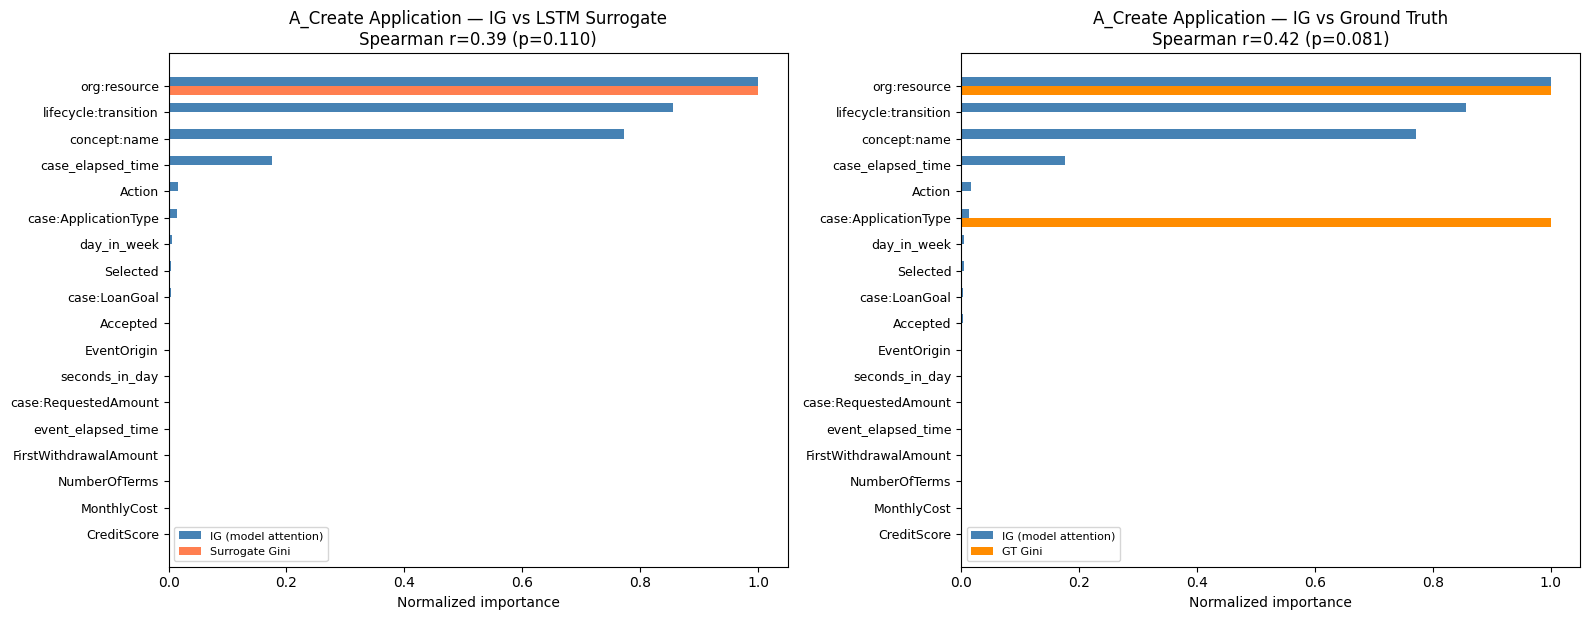


A_Create Application — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
2,org:resource,0.7365,1.0,0.5
4,lifecycle:transition,0.6306,0.0,0.0
0,concept:name,0.5685,0.0,0.0
9,case_elapsed_time,0.1292,0.0,0.0
1,Action,0.0118,0.0,0.0
6,case:ApplicationType,0.0099,0.0,0.5
11,day_in_week,0.0040,0.0,0.0
8,Selected,0.0034,0.0,0.0
5,case:LoanGoal,0.0024,0.0,0.0
7,Accepted,0.0019,0.0,0.0


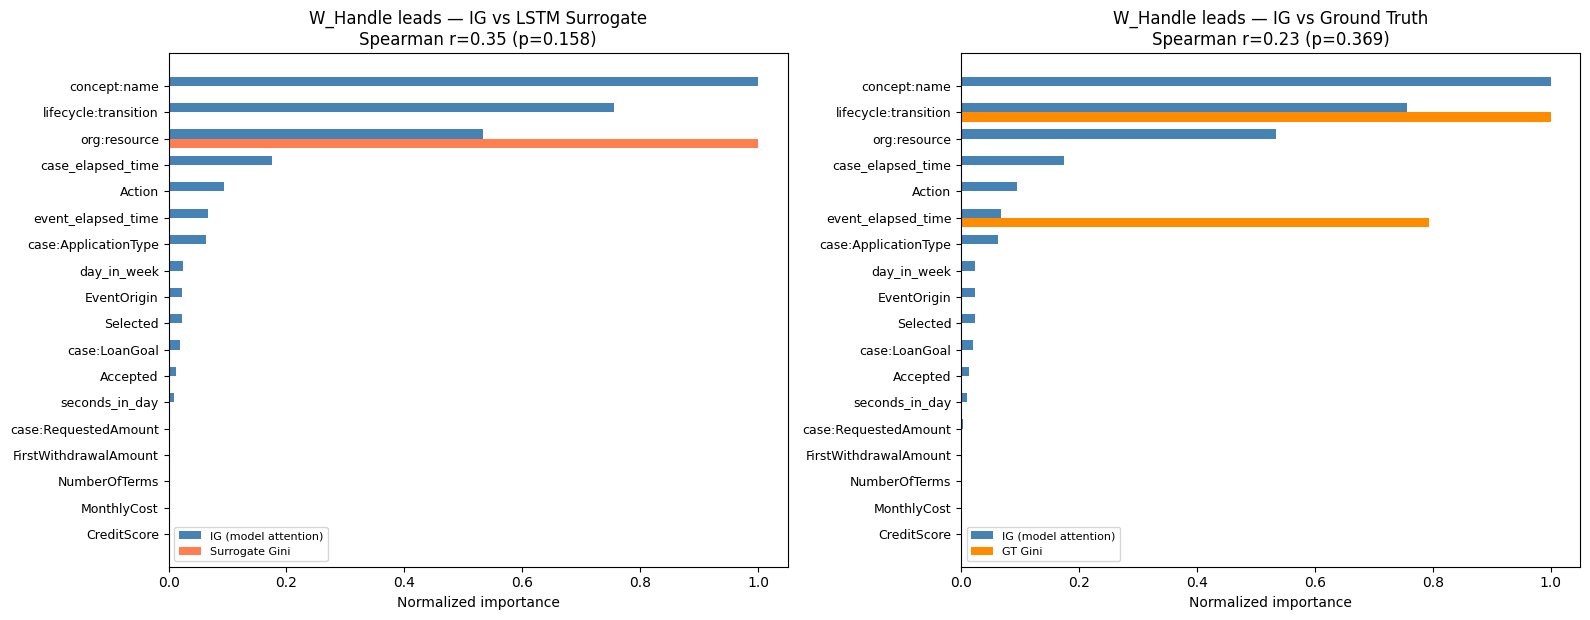


W_Handle leads — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,concept:name,1.2631,0.0000,0.0000
4,lifecycle:transition,0.9554,0.0000,0.5576
2,org:resource,0.6744,0.4908,0.0000
9,case_elapsed_time,0.2210,0.0000,0.0000
1,Action,0.1197,0.0000,0.0000
10,event_elapsed_time,0.0855,0.0001,0.4424
6,case:ApplicationType,0.0793,0.0000,0.0000
11,day_in_week,0.0308,0.0000,0.0000
3,EventOrigin,0.0289,0.0000,0.0000
8,Selected,0.0288,0.0000,0.0000


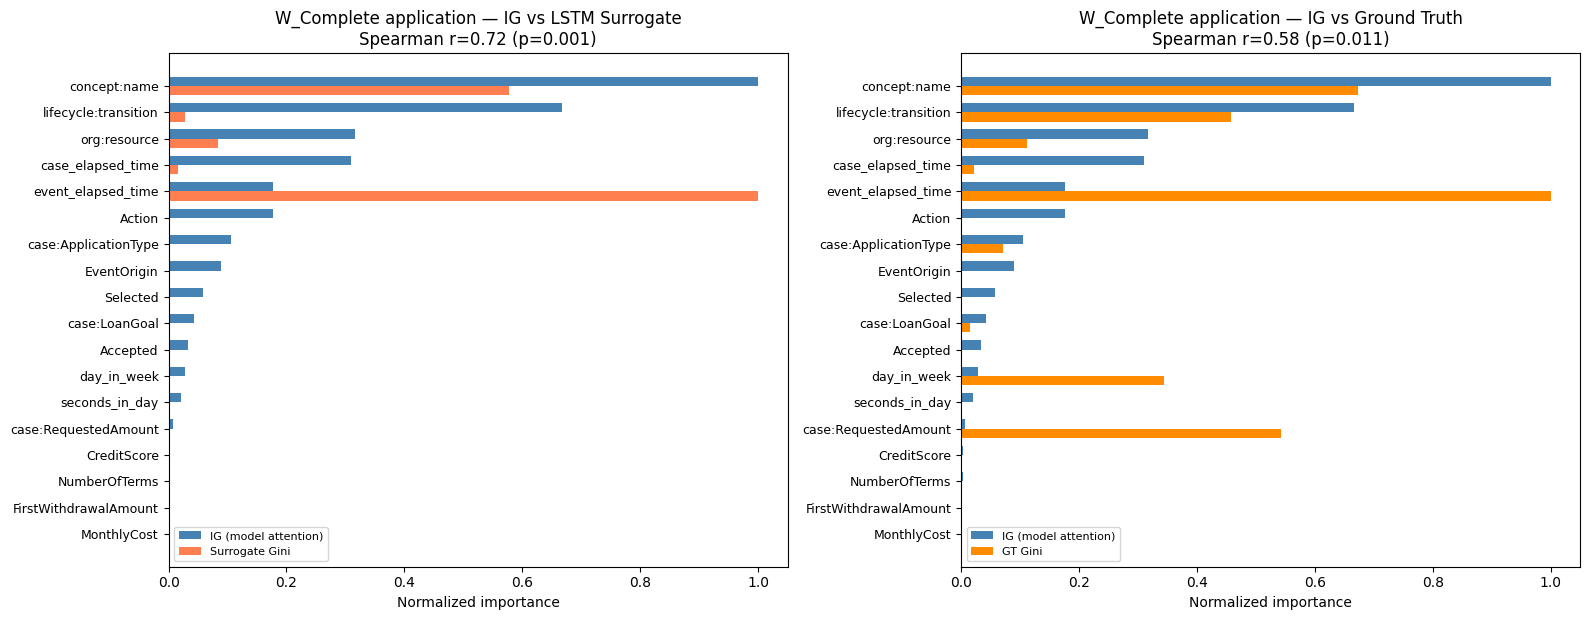


W_Complete application — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,concept:name,1.9295,0.2505,0.1823
4,lifecycle:transition,1.2864,0.0124,0.1242
2,org:resource,0.6111,0.0367,0.0303
9,case_elapsed_time,0.5979,0.0071,0.0059
10,event_elapsed_time,0.3416,0.4338,0.2711
1,Action,0.3408,0.0000,0.0000
6,case:ApplicationType,0.2031,0.0003,0.0194
3,EventOrigin,0.1721,0.0000,0.0000
8,Selected,0.1121,0.0000,0.0000
5,case:LoanGoal,0.0821,0.0000,0.0043


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_70032/1844980839.py:64: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])


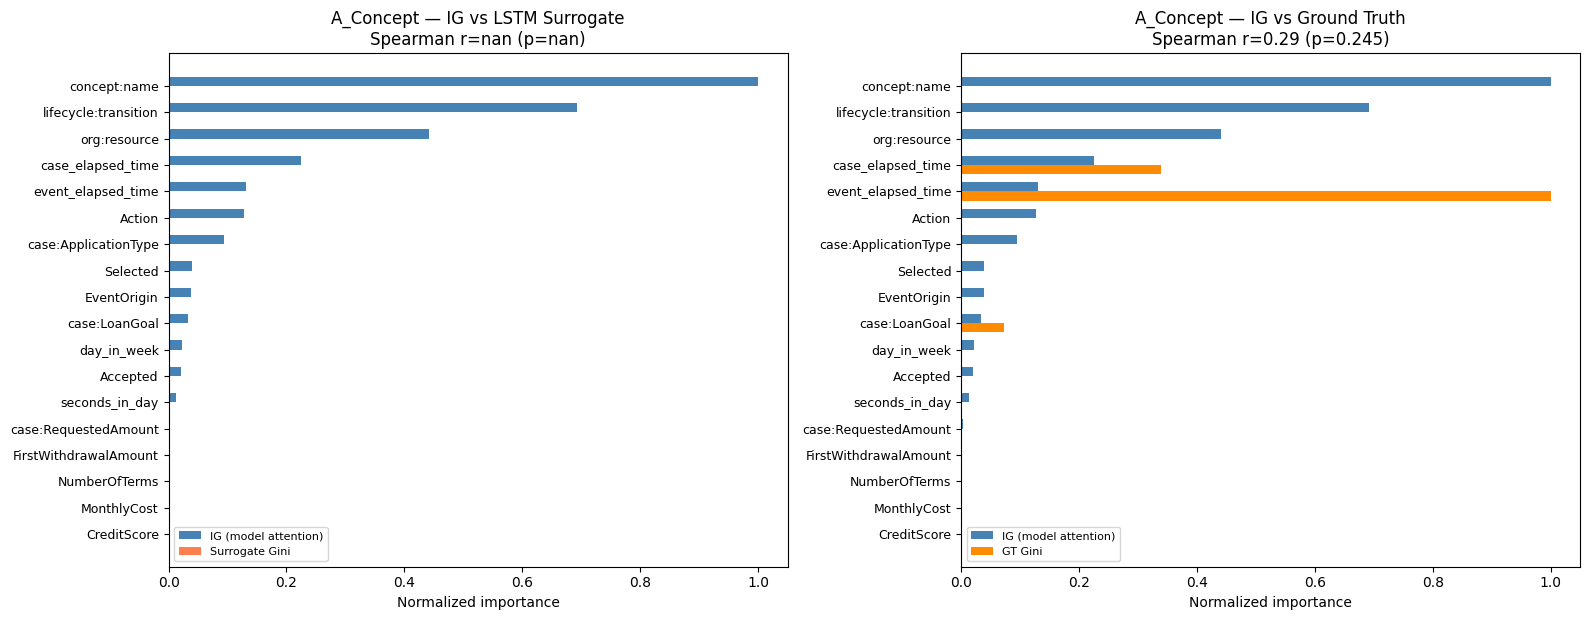


A_Concept — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,concept:name,1.3432,0.0,0.0000
4,lifecycle:transition,0.9304,0.0,0.0000
2,org:resource,0.5928,0.0,0.0000
9,case_elapsed_time,0.3025,0.0,0.2012
10,event_elapsed_time,0.1753,0.0,0.5944
1,Action,0.1708,0.0,0.0000
6,case:ApplicationType,0.1267,0.0,0.0000
8,Selected,0.0530,0.0,0.0000
3,EventOrigin,0.0511,0.0,0.0000
5,case:LoanGoal,0.0444,0.0,0.0433


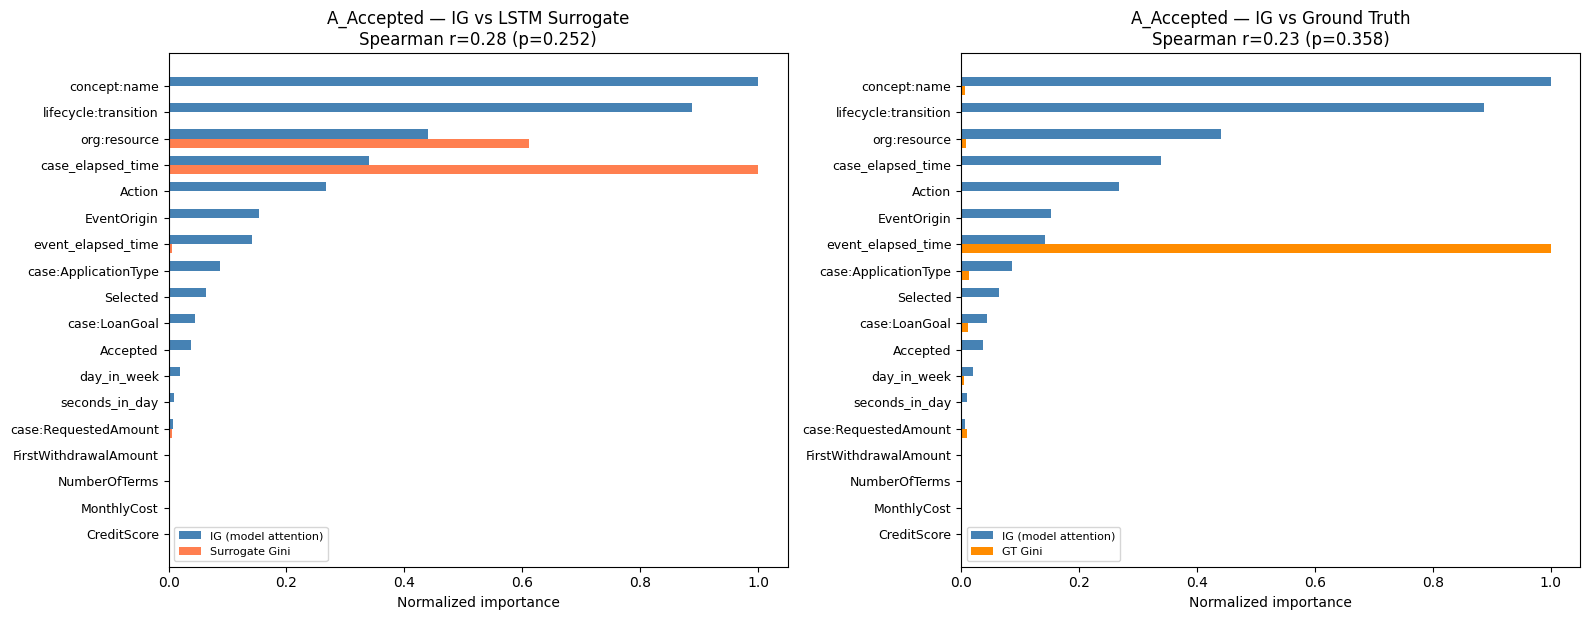


A_Accepted — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,concept:name,1.5635,0.0000,0.0069
4,lifecycle:transition,1.3882,0.0000,0.0000
2,org:resource,0.6887,0.3739,0.0072
9,case_elapsed_time,0.5310,0.6122,0.0000
1,Action,0.4187,0.0000,0.0000
3,EventOrigin,0.2388,0.0000,0.0000
10,event_elapsed_time,0.2213,0.0040,0.9397
6,case:ApplicationType,0.1354,0.0000,0.0128
8,Selected,0.1002,0.0000,0.0000
5,case:LoanGoal,0.0692,0.0002,0.0106


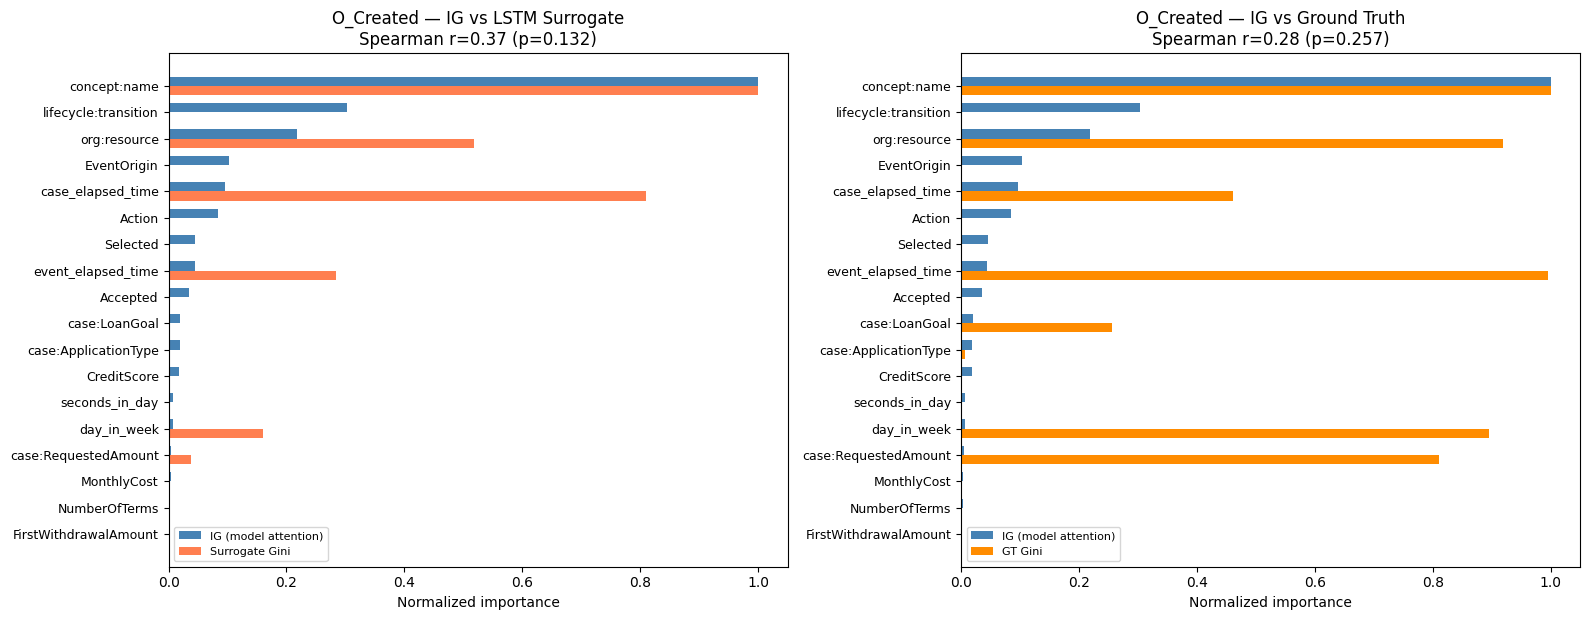


O_Created — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,concept:name,2.9603,0.2507,0.1230
4,lifecycle:transition,0.8968,0.0000,0.0000
2,org:resource,0.6468,0.1300,0.1132
3,EventOrigin,0.3043,0.0000,0.0000
9,case_elapsed_time,0.2835,0.2029,0.0569
1,Action,0.2493,0.0000,0.0000
8,Selected,0.1343,0.0000,0.0000
10,event_elapsed_time,0.1324,0.0712,0.1225
7,Accepted,0.1027,0.0000,0.0000
5,case:LoanGoal,0.0589,0.0000,0.0315


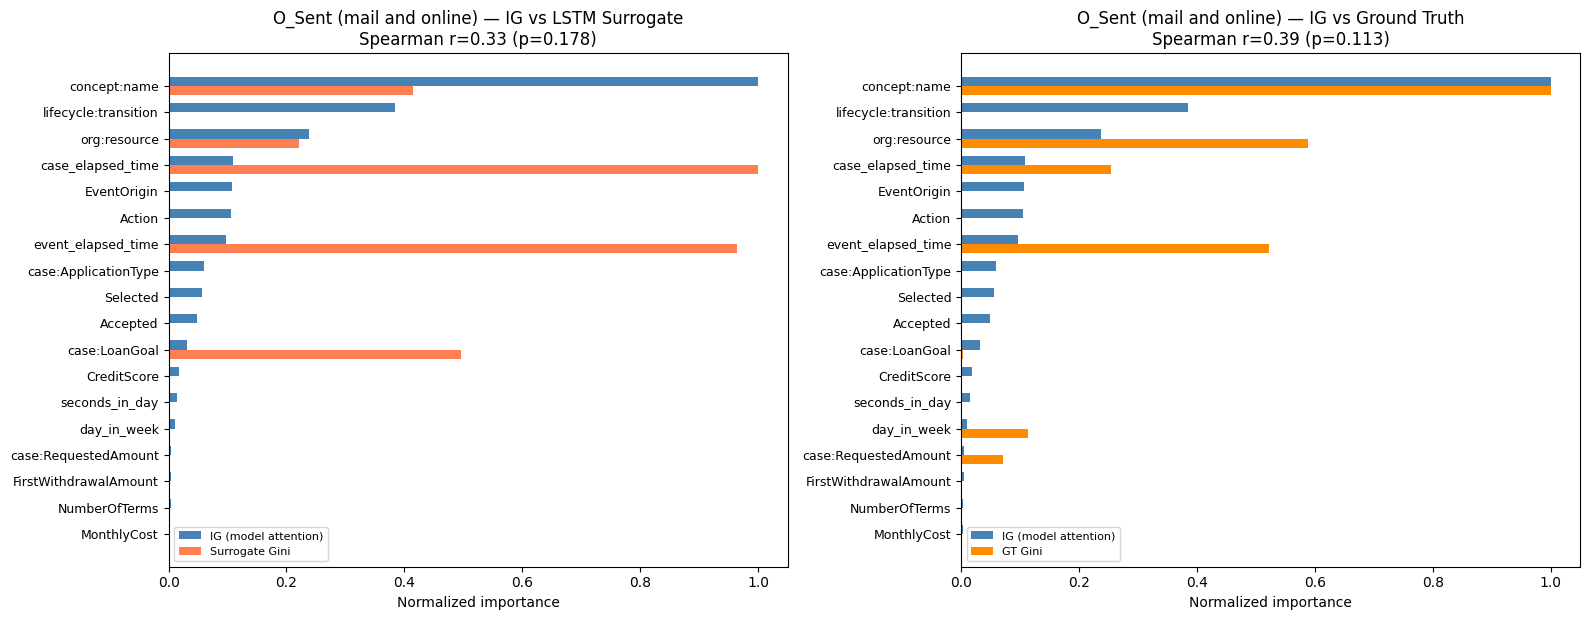


O_Sent (mail and online) — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,concept:name,2.7276,0.0860,0.2249
4,lifecycle:transition,1.0491,0.0000,0.0000
2,org:resource,0.6494,0.0459,0.1323
9,case_elapsed_time,0.2979,0.2075,0.0572
3,EventOrigin,0.2920,0.0000,0.0000
1,Action,0.2866,0.0000,0.0000
10,event_elapsed_time,0.2647,0.2002,0.1174
6,case:ApplicationType,0.1626,0.0000,0.0000
8,Selected,0.1524,0.0000,0.0000
7,Accepted,0.1333,0.0000,0.0000


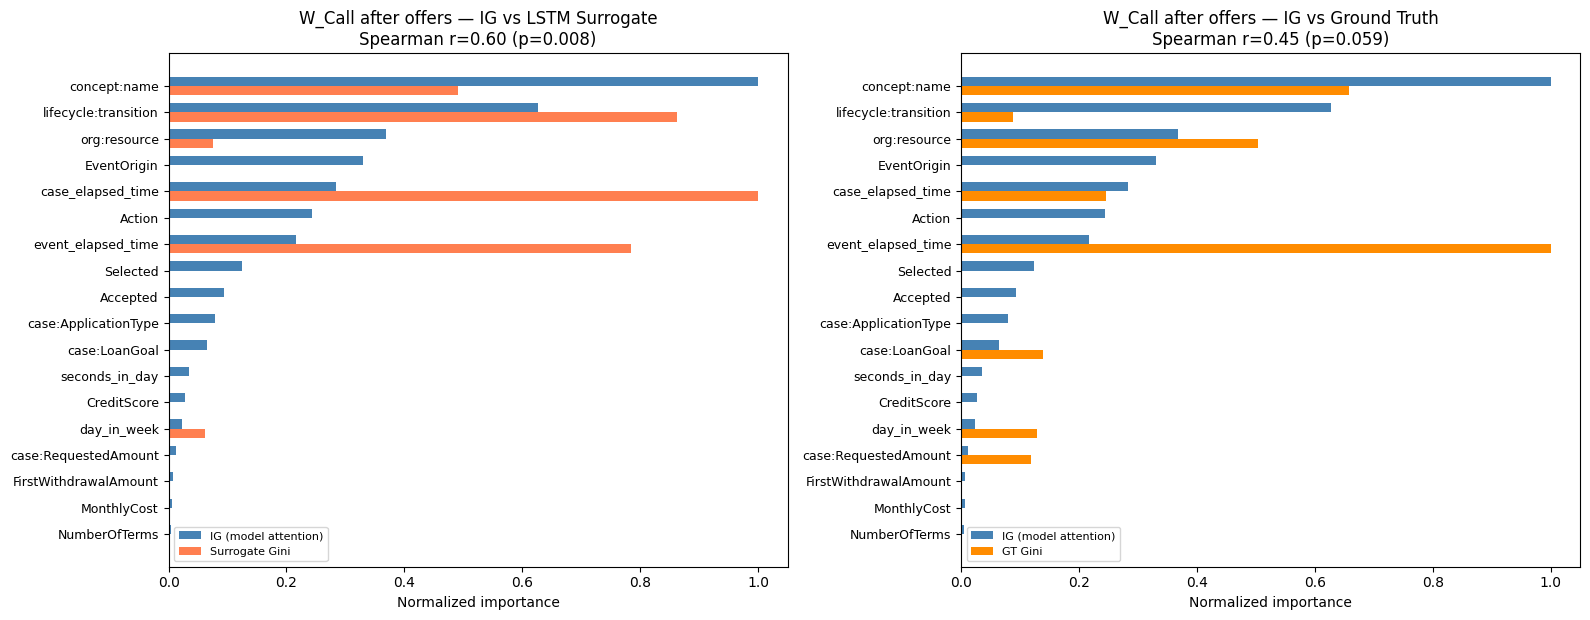


W_Call after offers — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,concept:name,2.0798,0.1264,0.1891
4,lifecycle:transition,1.3040,0.2218,0.0254
2,org:resource,0.7661,0.0194,0.1446
3,EventOrigin,0.6861,0.0000,0.0000
9,case_elapsed_time,0.5895,0.2570,0.0707
1,Action,0.5074,0.0000,0.0000
10,event_elapsed_time,0.4505,0.2018,0.2875
8,Selected,0.2583,0.0000,0.0000
7,Accepted,0.1944,0.0000,0.0000
6,case:ApplicationType,0.1641,0.0000,0.0000


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_70032/1844980839.py:64: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])


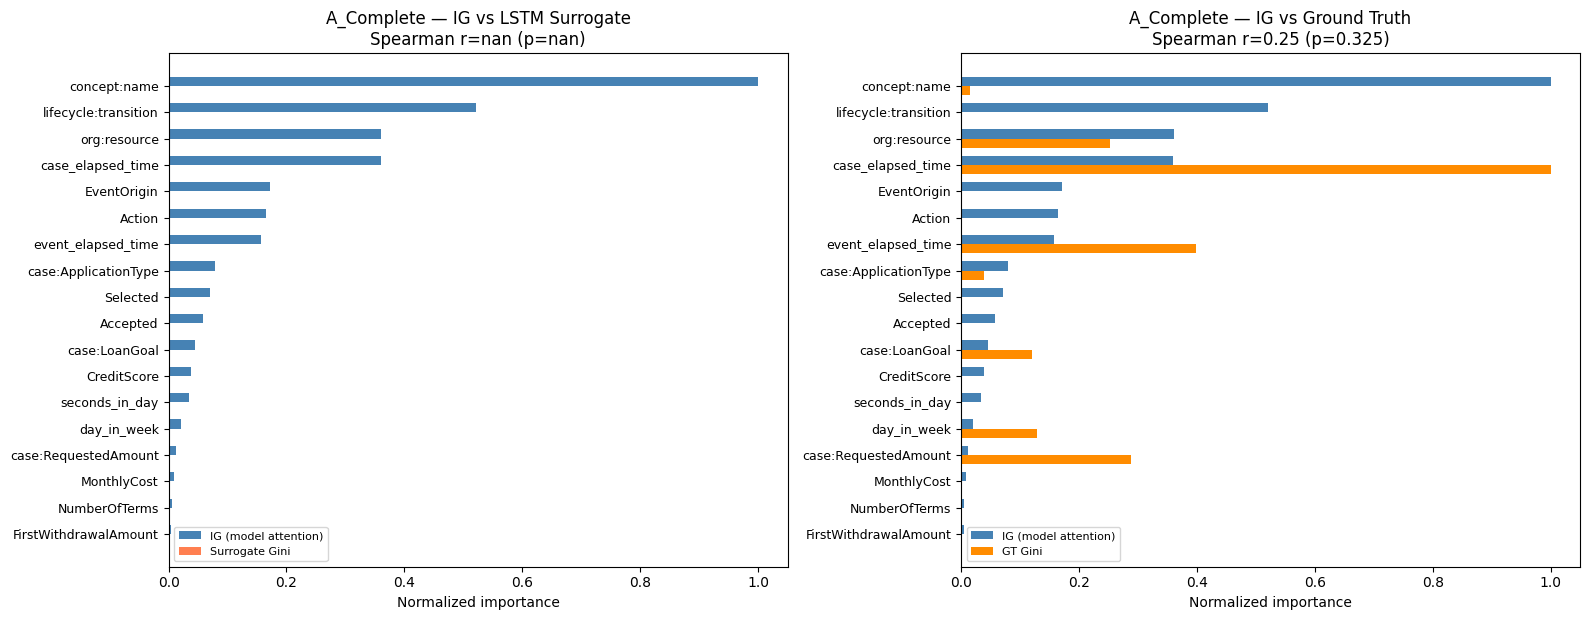


A_Complete — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,concept:name,2.1809,0.0,0.0059
4,lifecycle:transition,1.1371,0.0,0.0000
2,org:resource,0.7875,0.0,0.1037
9,case_elapsed_time,0.7845,0.0,0.4111
3,EventOrigin,0.3750,0.0,0.0000
1,Action,0.3589,0.0,0.0000
10,event_elapsed_time,0.3424,0.0,0.1639
6,case:ApplicationType,0.1720,0.0,0.0160
8,Selected,0.1548,0.0,0.0000
7,Accepted,0.1273,0.0,0.0000


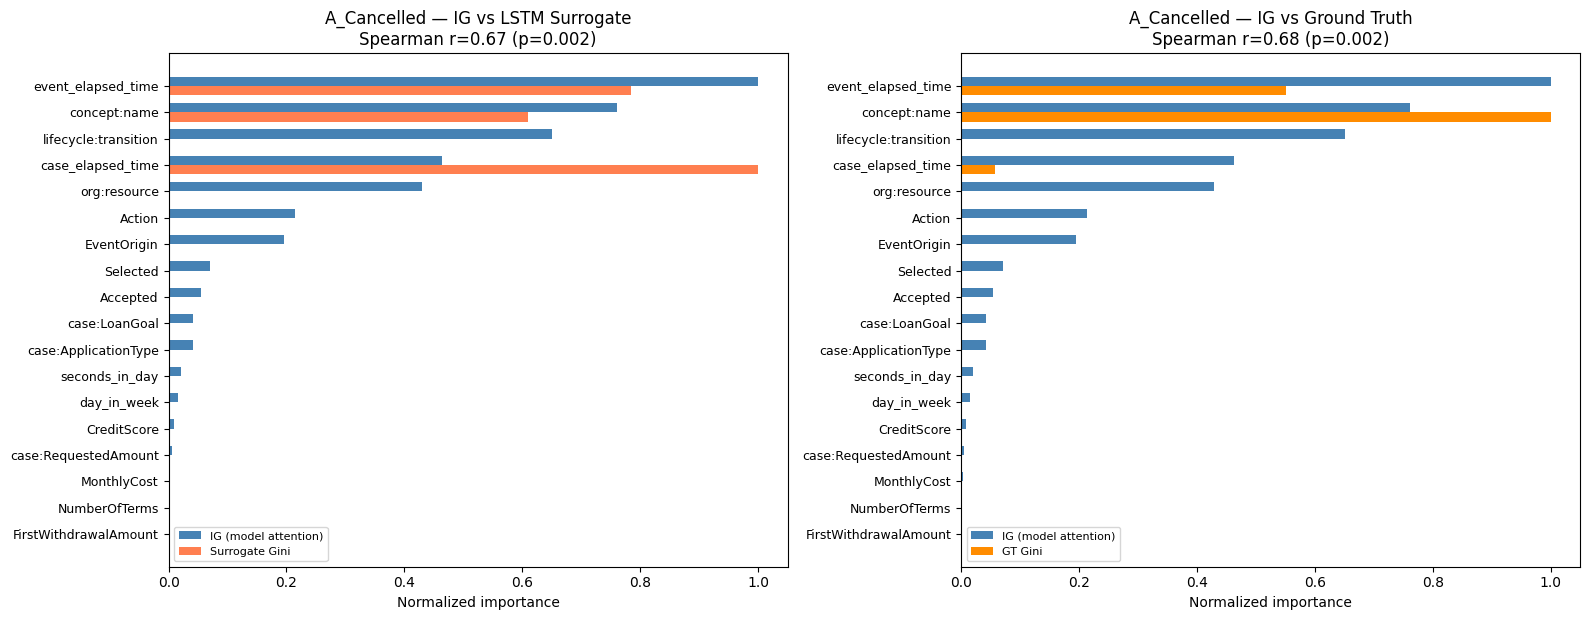


A_Cancelled — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
10,event_elapsed_time,1.2359,0.2740,0.3304
0,concept:name,0.9409,0.2128,0.5995
4,lifecycle:transition,0.8047,0.0000,0.0000
9,case_elapsed_time,0.5731,0.3494,0.0343
2,org:resource,0.5307,0.0000,0.0000
1,Action,0.2649,0.0000,0.0000
3,EventOrigin,0.2419,0.0000,0.0000
8,Selected,0.0878,0.0000,0.0000
7,Accepted,0.0678,0.0000,0.0000
5,case:LoanGoal,0.0517,0.0000,0.0000


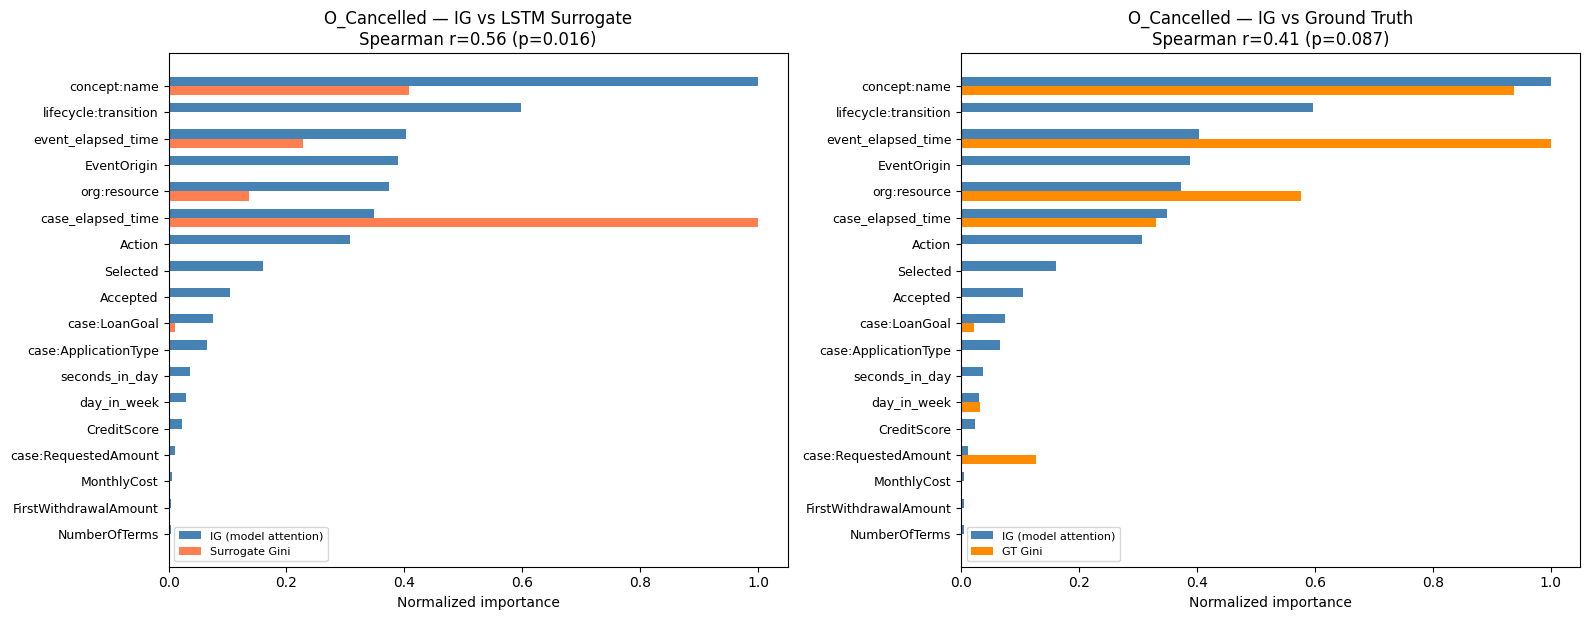


O_Cancelled — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,concept:name,2.1649,0.2101,0.2620
4,lifecycle:transition,1.2928,0.0000,0.0000
10,event_elapsed_time,0.8735,0.1171,0.2792
3,EventOrigin,0.8416,0.0000,0.0000
2,org:resource,0.8080,0.0702,0.1608
9,case_elapsed_time,0.7552,0.5149,0.0925
1,Action,0.6646,0.0000,0.0000
8,Selected,0.3475,0.0000,0.0000
7,Accepted,0.2272,0.0000,0.0000
5,case:LoanGoal,0.1630,0.0060,0.0060


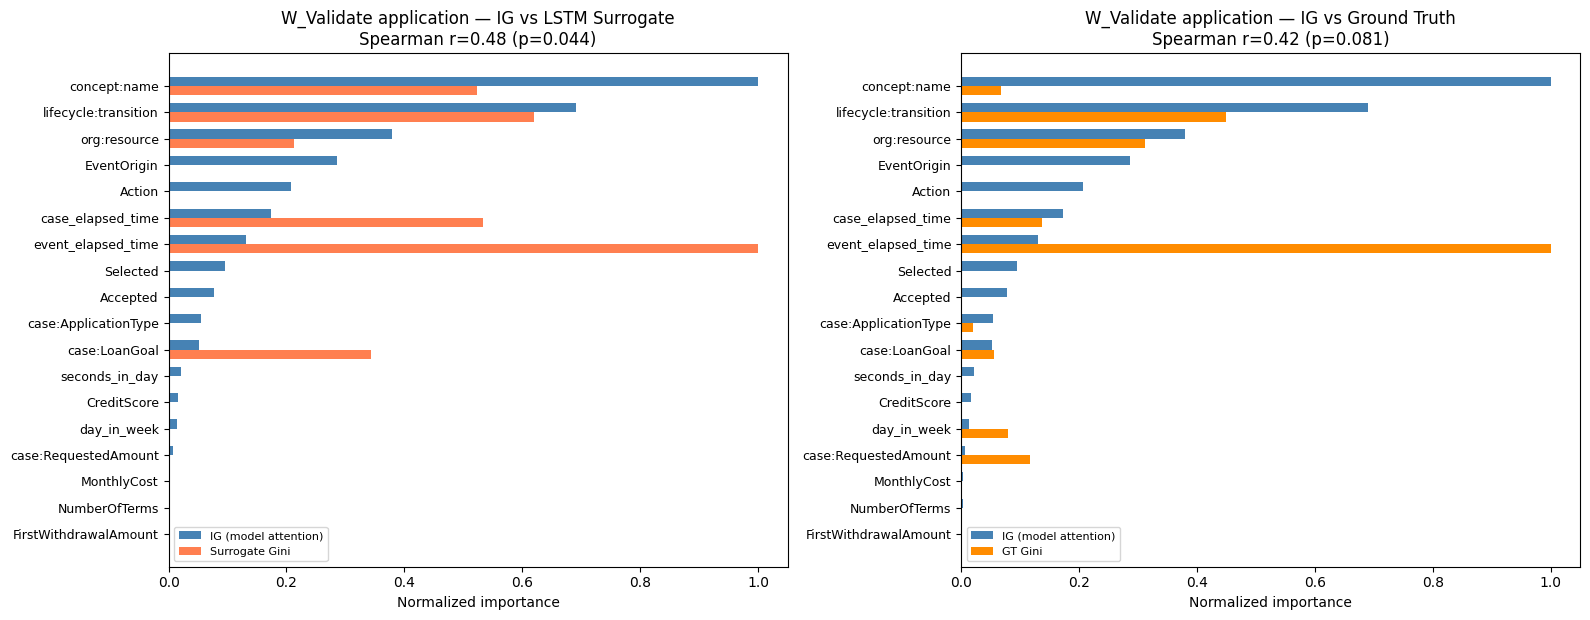


W_Validate application — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,concept:name,2.3260,0.1603,0.0255
4,lifecycle:transition,1.6059,0.1900,0.1681
2,org:resource,0.8831,0.0650,0.1167
3,EventOrigin,0.6648,0.0000,0.0000
1,Action,0.4815,0.0000,0.0000
9,case_elapsed_time,0.4022,0.1632,0.0512
10,event_elapsed_time,0.3037,0.3064,0.3746
8,Selected,0.2212,0.0000,0.0000
7,Accepted,0.1792,0.0000,0.0000
6,case:ApplicationType,0.1275,0.0000,0.0073


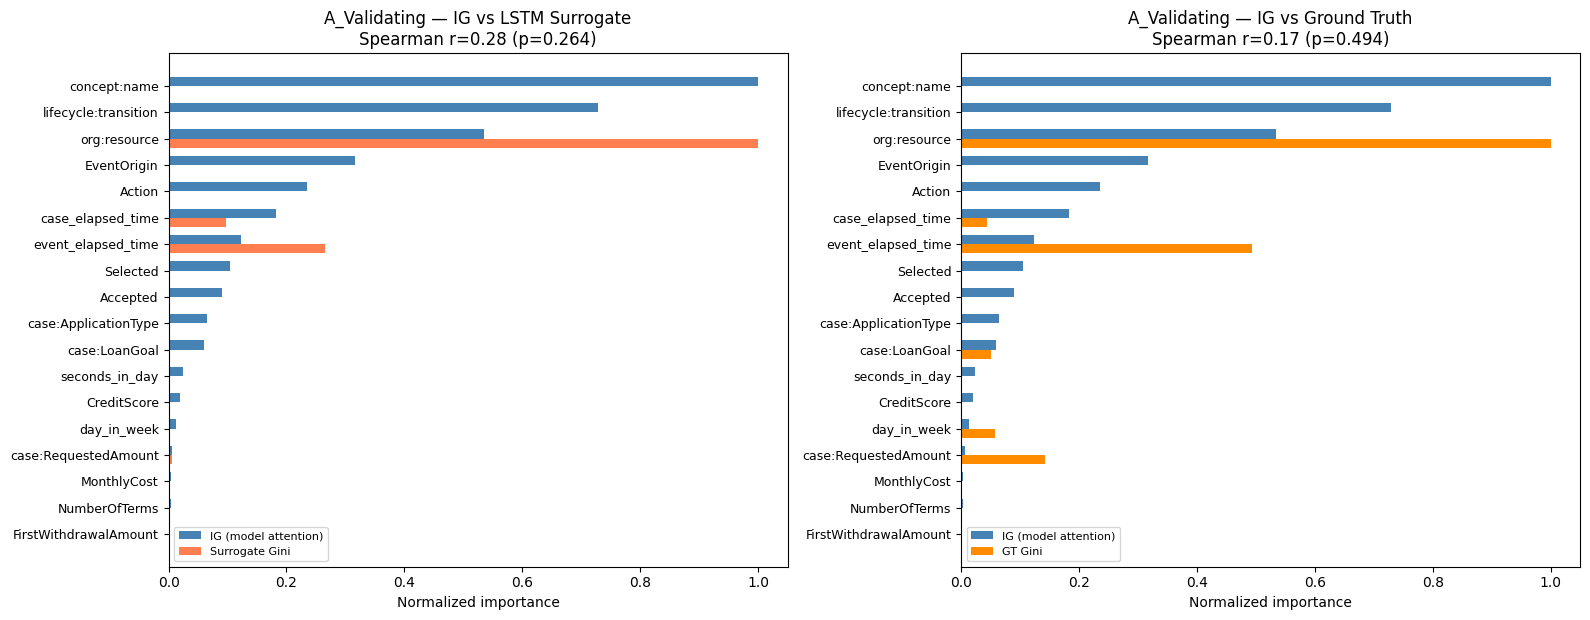


A_Validating — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,concept:name,1.5937,0.0018,0.0000
4,lifecycle:transition,1.1611,0.0000,0.0000
2,org:resource,0.8520,0.7208,0.5108
3,EventOrigin,0.5048,0.0000,0.0000
1,Action,0.3746,0.0000,0.0000
9,case_elapsed_time,0.2916,0.0698,0.0228
10,event_elapsed_time,0.1959,0.1911,0.2520
8,Selected,0.1670,0.0000,0.0000
7,Accepted,0.1444,0.0000,0.0000
6,case:ApplicationType,0.1028,0.0000,0.0000


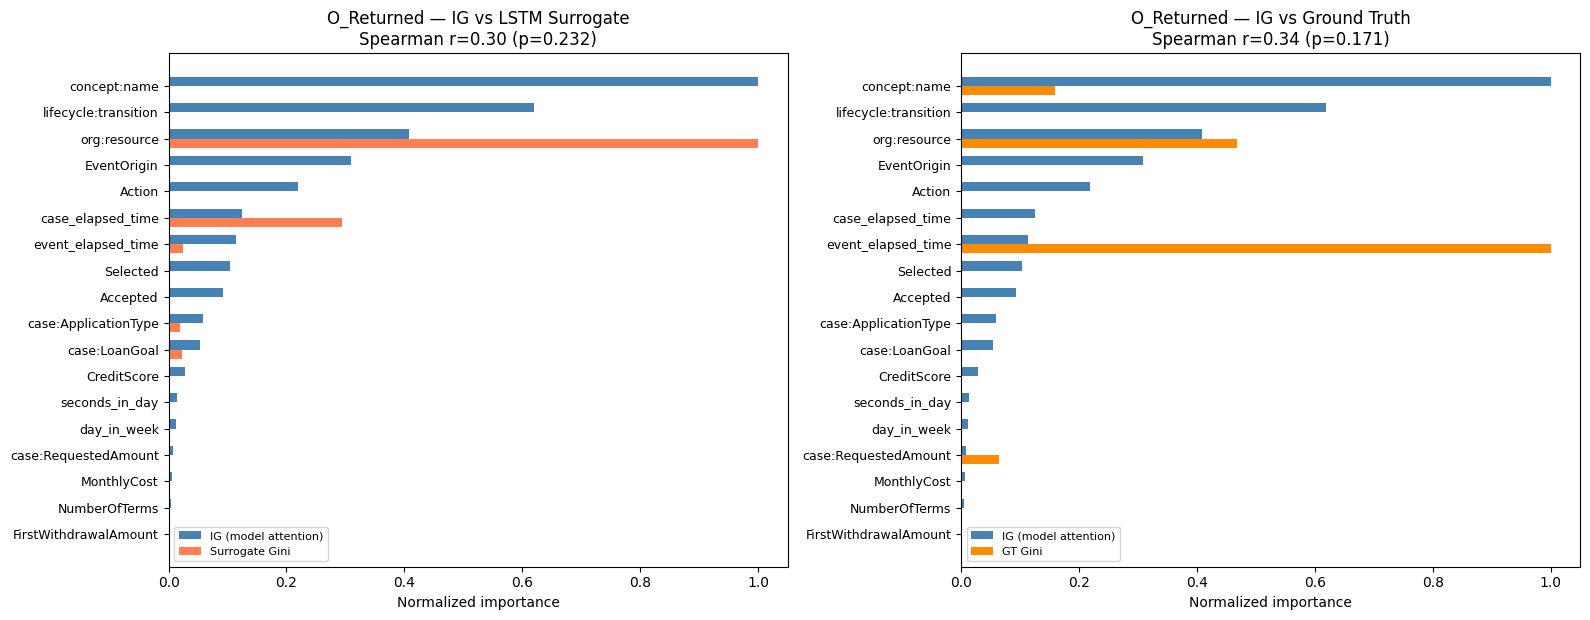


O_Returned — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,concept:name,2.0802,0.0000,0.0731
4,lifecycle:transition,1.2883,0.0000,0.0000
2,org:resource,0.8496,0.6077,0.2138
3,EventOrigin,0.6433,0.0000,0.0000
1,Action,0.4557,0.0000,0.0000
9,case_elapsed_time,0.2593,0.1785,0.0000
10,event_elapsed_time,0.2361,0.0152,0.4566
8,Selected,0.2156,0.0000,0.0000
7,Accepted,0.1932,0.0000,0.0000
6,case:ApplicationType,0.1230,0.0113,0.0000


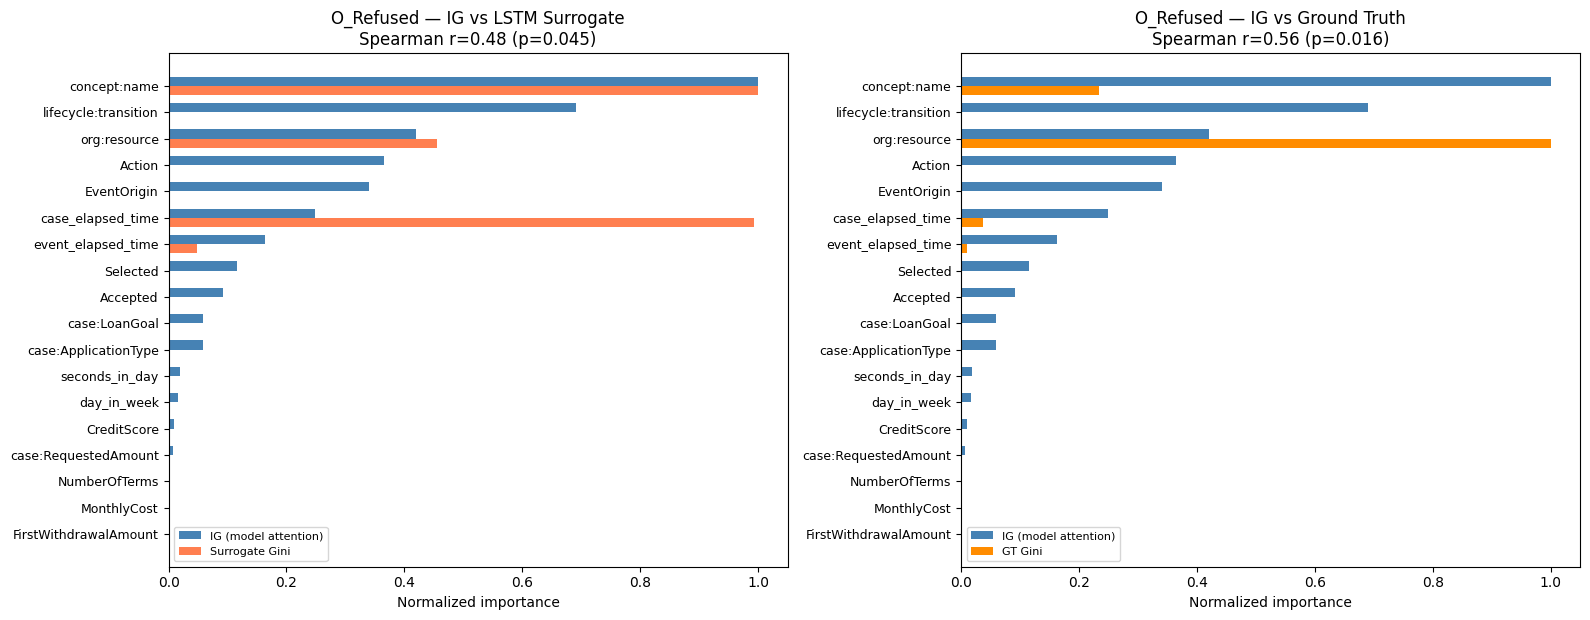


O_Refused — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,concept:name,1.8975,0.3216,0.1132
4,lifecycle:transition,1.3105,0.0000,0.0000
2,org:resource,0.7973,0.1464,0.4848
1,Action,0.6933,0.0000,0.0000
3,EventOrigin,0.6465,0.0000,0.0000
9,case_elapsed_time,0.4725,0.3194,0.0180
10,event_elapsed_time,0.3103,0.0153,0.0052
8,Selected,0.2196,0.0000,0.0000
7,Accepted,0.1737,0.0000,0.0000
5,case:LoanGoal,0.1122,0.0000,0.0000


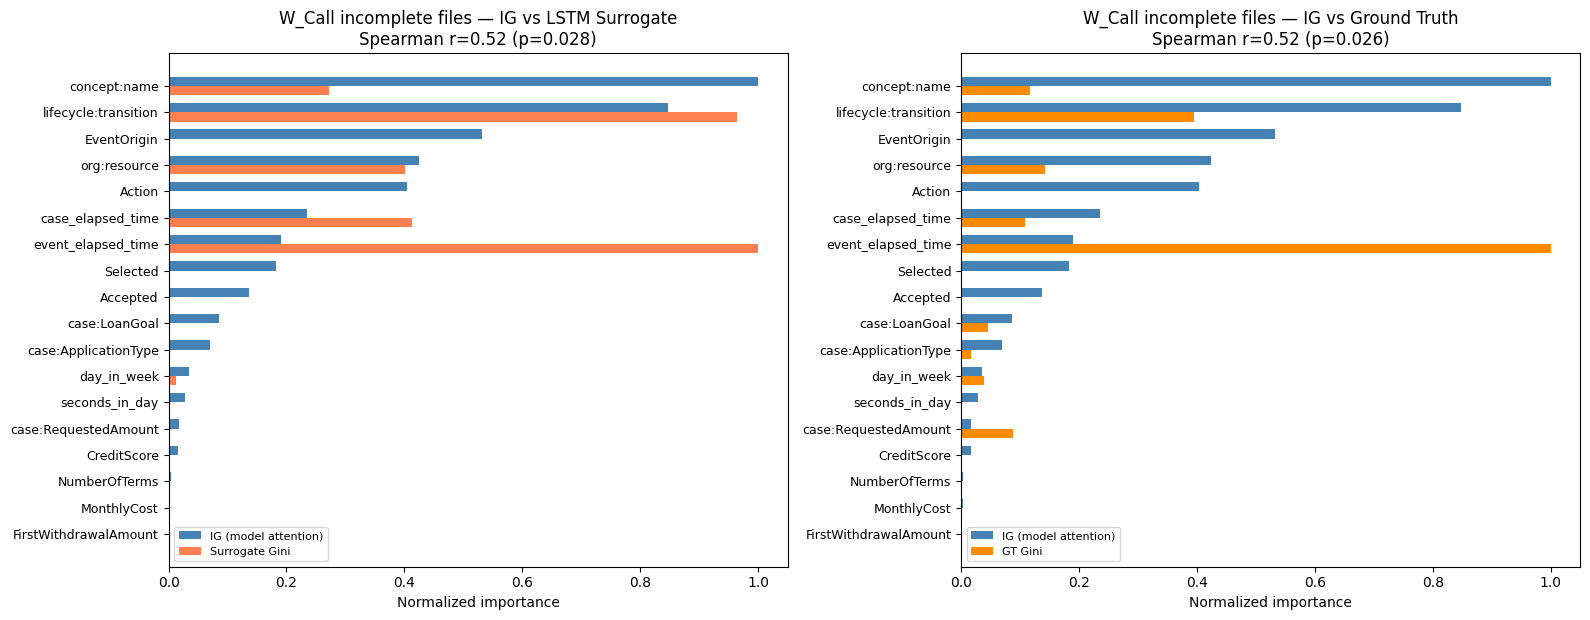


W_Call incomplete files — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,concept:name,1.7123,0.0743,0.0456
4,lifecycle:transition,1.4510,0.2638,0.1536
3,EventOrigin,0.9114,0.0000,0.0000
2,org:resource,0.7263,0.1096,0.0550
1,Action,0.6912,0.0000,0.0000
9,case_elapsed_time,0.4031,0.1129,0.0422
10,event_elapsed_time,0.3260,0.2735,0.3885
8,Selected,0.3122,0.0000,0.0000
7,Accepted,0.2338,0.0000,0.0000
5,case:LoanGoal,0.1468,0.0000,0.0180


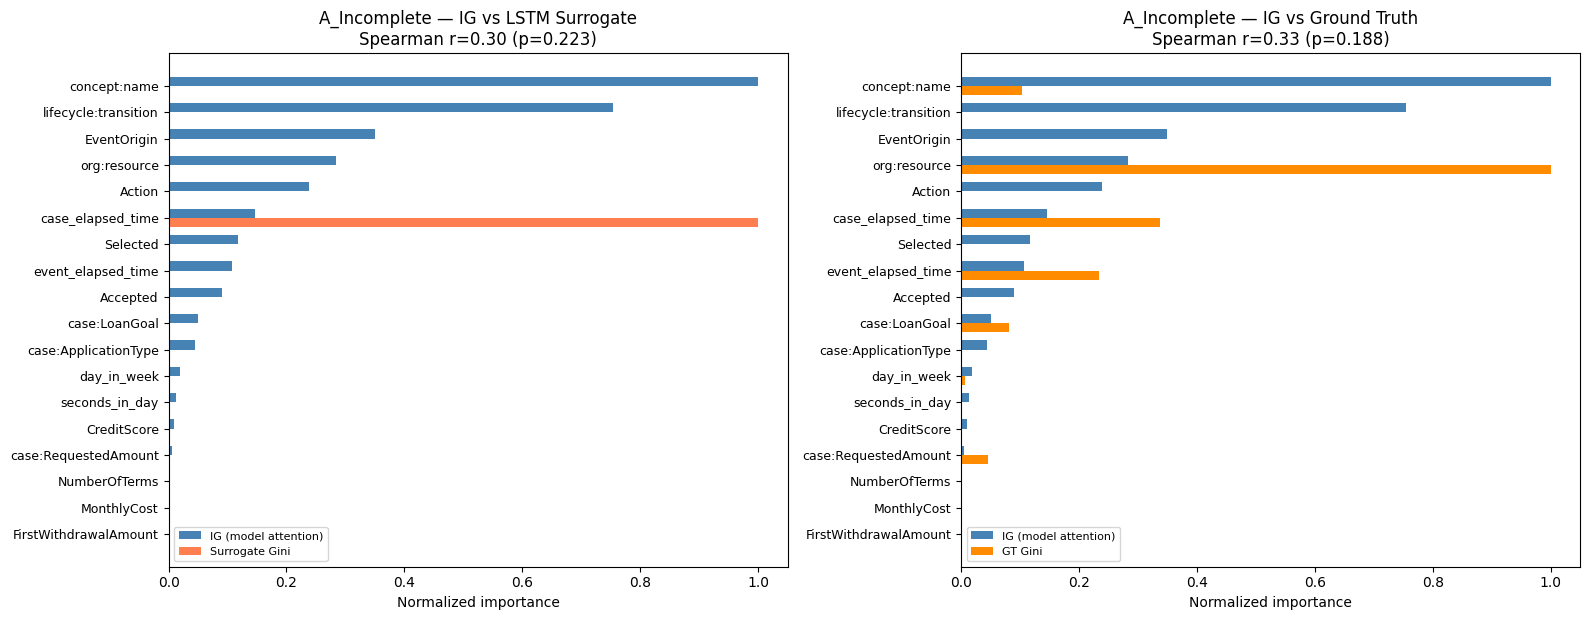


A_Incomplete — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,concept:name,2.0739,0.0,0.0544
4,lifecycle:transition,1.5644,0.0,0.0000
3,EventOrigin,0.7246,0.0,0.0000
2,org:resource,0.5884,0.0,0.5290
1,Action,0.4942,0.0,0.0000
9,case_elapsed_time,0.3037,1.0,0.1782
8,Selected,0.2426,0.0,0.0000
10,event_elapsed_time,0.2222,0.0,0.1236
7,Accepted,0.1862,0.0,0.0000
5,case:LoanGoal,0.1039,0.0,0.0430


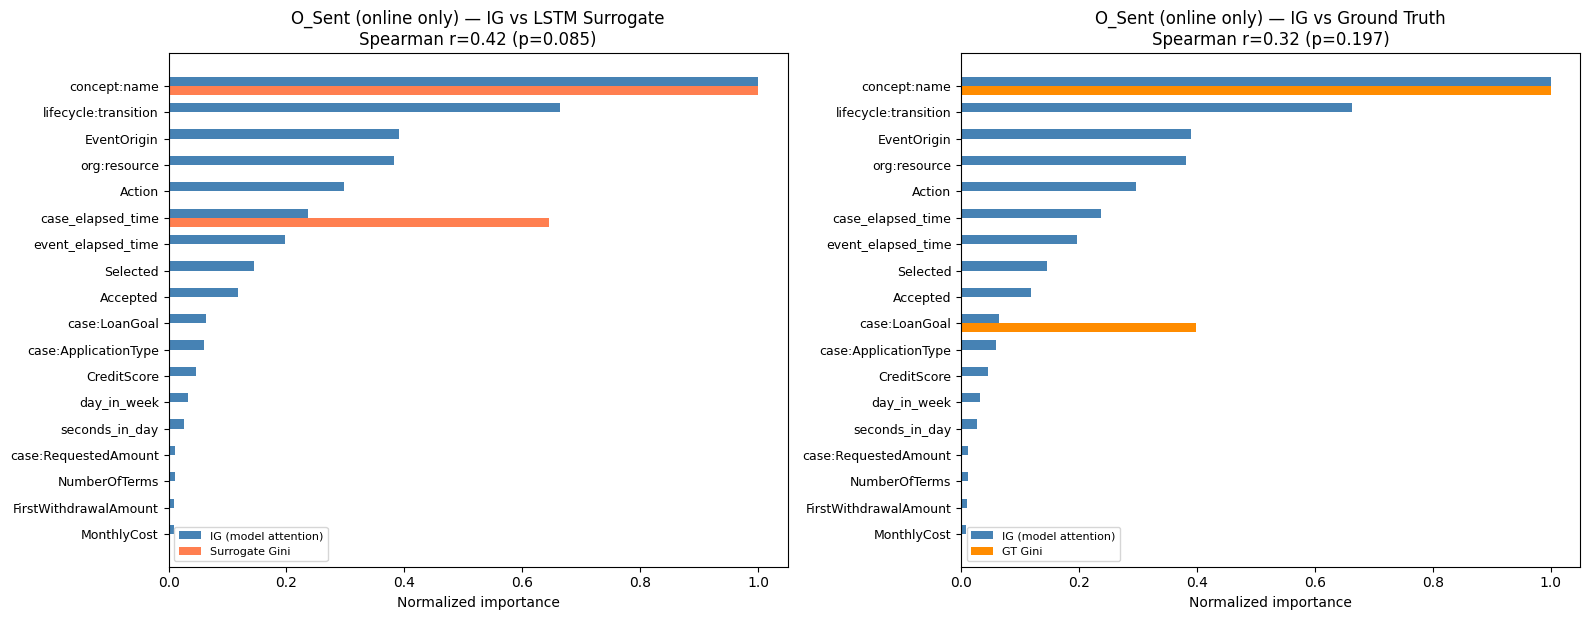


O_Sent (online only) — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,concept:name,1.6975,0.4634,0.7146
4,lifecycle:transition,1.1265,0.0000,0.0000
3,EventOrigin,0.6626,0.0000,0.0000
2,org:resource,0.6477,0.0000,0.0000
1,Action,0.5043,0.0000,0.0000
9,case_elapsed_time,0.4016,0.2991,0.0000
10,event_elapsed_time,0.3352,0.0000,0.0008
8,Selected,0.2465,0.0000,0.0000
7,Accepted,0.2012,0.0000,0.0000
5,case:LoanGoal,0.1078,0.0000,0.2846


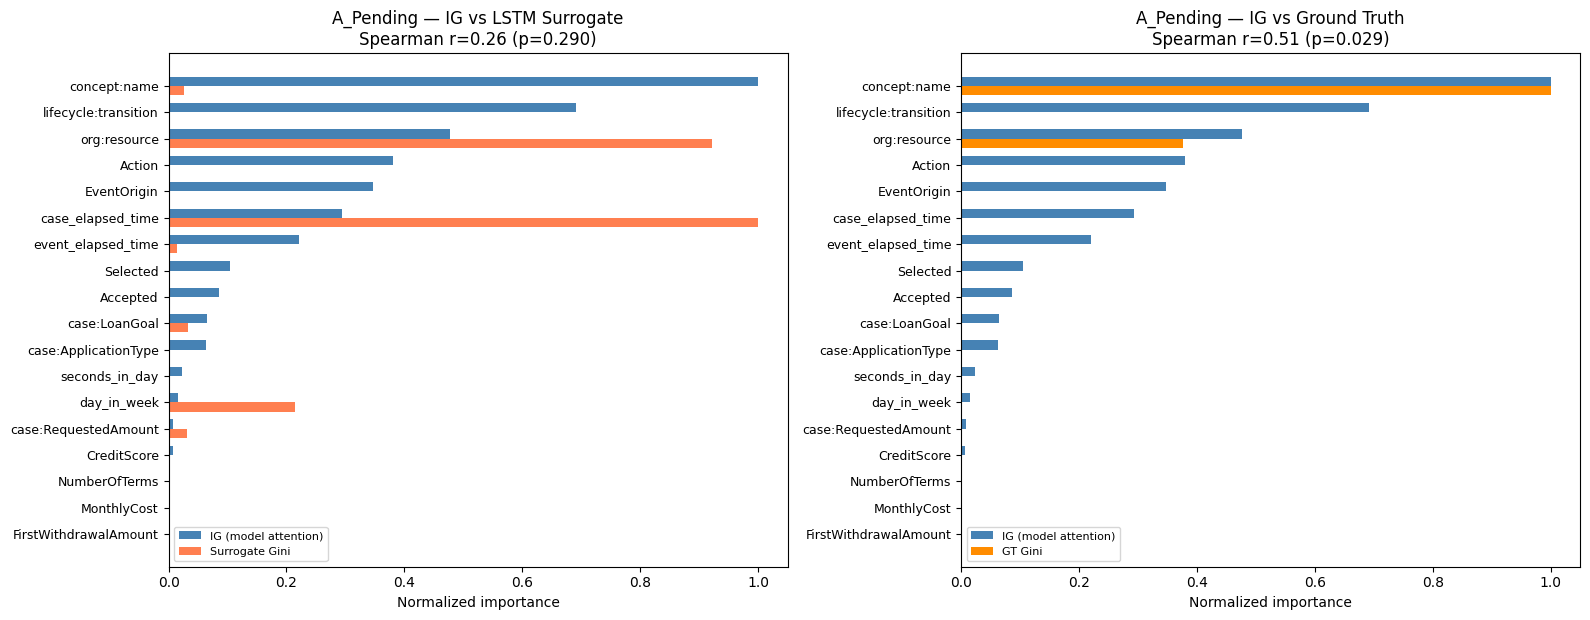


A_Pending — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,concept:name,1.8369,0.0110,0.6444
4,lifecycle:transition,1.2699,0.0000,0.0000
2,org:resource,0.8758,0.3961,0.2429
1,Action,0.6984,0.0000,0.0000
3,EventOrigin,0.6382,0.0000,0.0000
9,case_elapsed_time,0.5400,0.4296,0.0000
10,event_elapsed_time,0.4057,0.0062,0.0000
8,Selected,0.1914,0.0000,0.0000
7,Accepted,0.1582,0.0000,0.0000
5,case:LoanGoal,0.1181,0.0140,0.0000


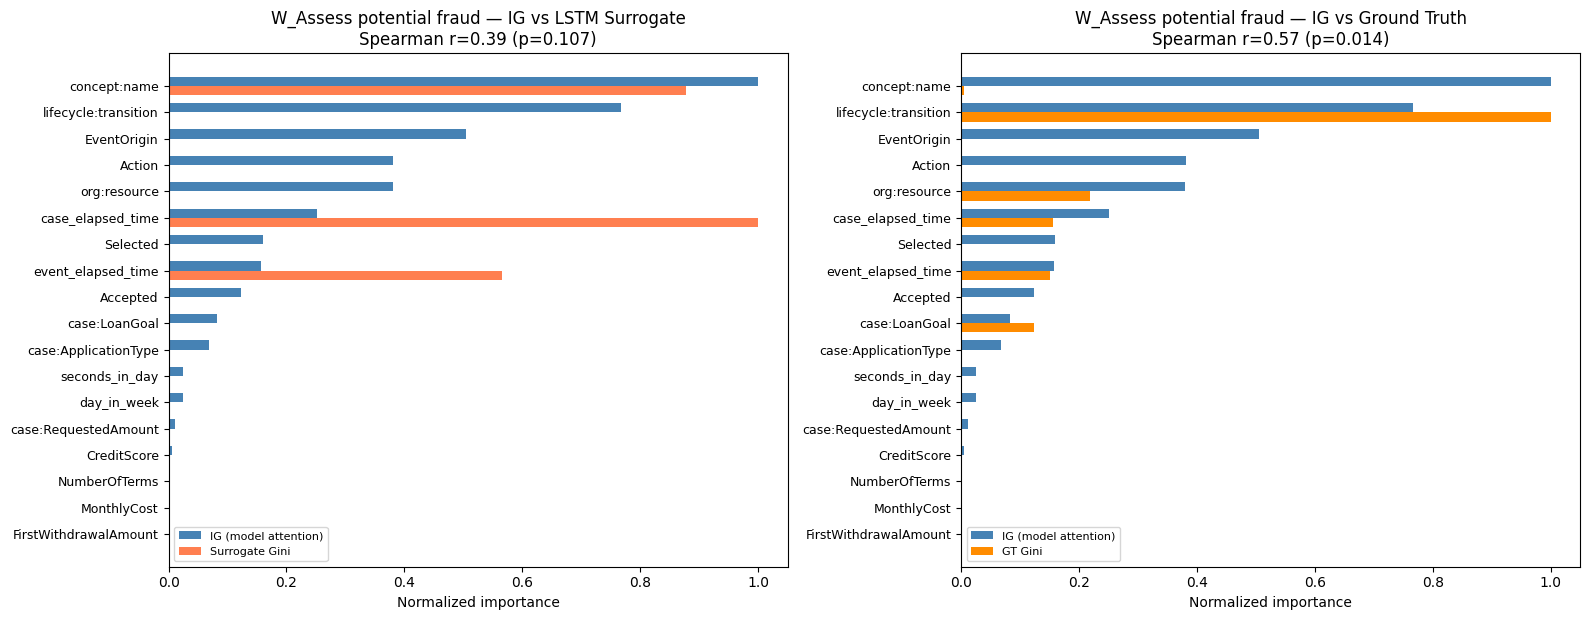


W_Assess potential fraud — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,concept:name,1.7315,0.2931,0.0029
4,lifecycle:transition,1.3285,0.0000,0.5837
3,EventOrigin,0.8737,0.0000,0.0000
1,Action,0.6601,0.0000,0.0000
2,org:resource,0.6581,0.0000,0.1281
9,case_elapsed_time,0.4356,0.3336,0.0907
8,Selected,0.2763,0.0000,0.0000
10,event_elapsed_time,0.2717,0.1890,0.0883
7,Accepted,0.2139,0.0000,0.0000
5,case:LoanGoal,0.1434,0.0000,0.0724


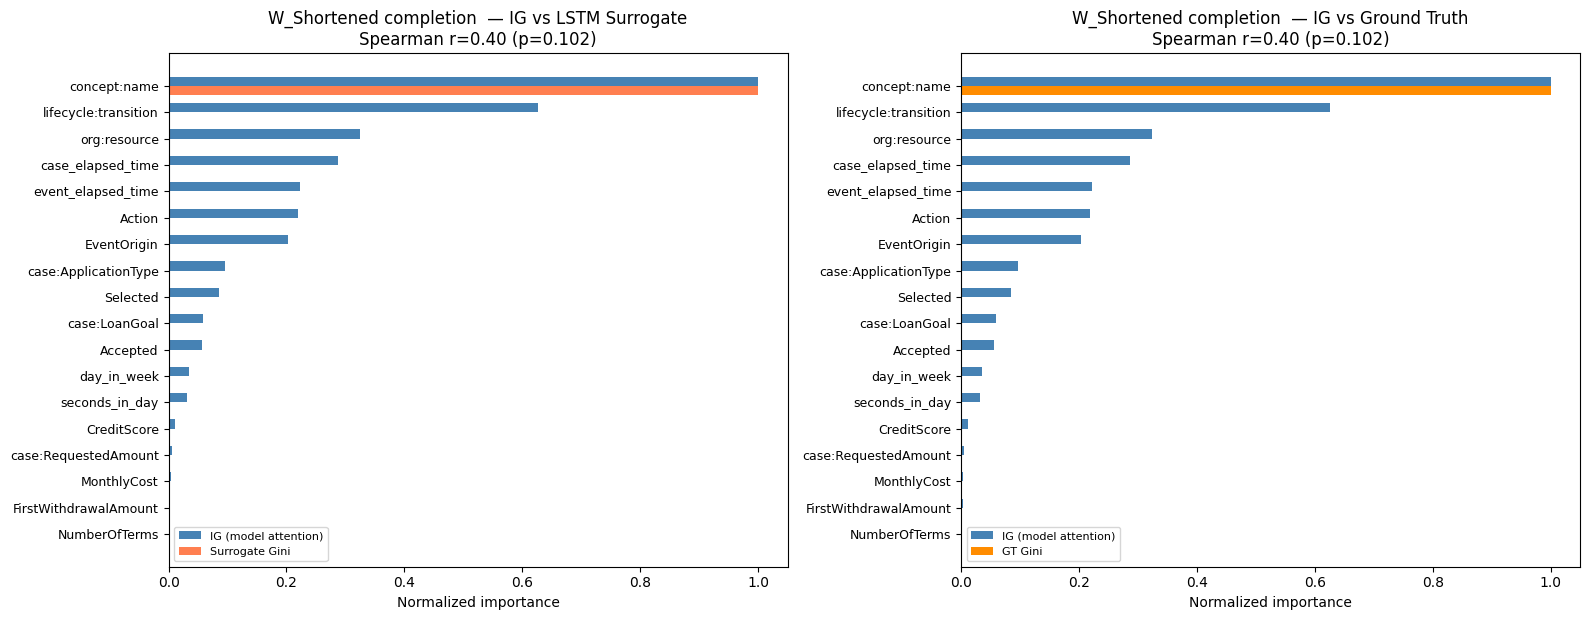


W_Shortened completion  — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,concept:name,2.2707,1.0,1.0
4,lifecycle:transition,1.4222,0.0,0.0
2,org:resource,0.7355,0.0,0.0
9,case_elapsed_time,0.6526,0.0,0.0
10,event_elapsed_time,0.5048,0.0,0.0
1,Action,0.4979,0.0,0.0
3,EventOrigin,0.4614,0.0,0.0
6,case:ApplicationType,0.2186,0.0,0.0
8,Selected,0.1939,0.0,0.0
5,case:LoanGoal,0.1328,0.0,0.0


In [6]:
for gateway_act in ig_results:
    ig_df = ig_results[gateway_act]
    gr = gateway_results[gateway_act]

    ig_features = [f for f in ALL_FEATURES if f in ig_df.columns]
    ig_mean = ig_df[ig_features].mean()

    surr_imp = dict(zip(gr['feature_names'], gr['clf_lstm'].feature_importances_))
    gt_imp = dict(zip(gr['feature_names'], gr['clf_gt'].feature_importances_))

    # Map model input features to surrogate engineered features
    comparison_rows = []
    for feat in ig_features:
        ig_val = ig_mean[feat]

        surr_key = f'last_{feat}' if f'last_{feat}' in surr_imp else feat
        surr_val = surr_imp.get(surr_key, 0.0)
        gt_val = gt_imp.get(surr_key, 0.0)

        # Aggregate related engineered features
        if feat == 'org:resource':
            for k in ['last_resource', 'n_unique_resources']:
                surr_val = max(surr_val, surr_imp.get(k, 0.0))
                gt_val = max(gt_val, gt_imp.get(k, 0.0))
        if feat == 'case_elapsed_time':
            surr_val = max(surr_val, surr_imp.get('total_elapsed_time', 0.0))
            gt_val = max(gt_val, gt_imp.get('total_elapsed_time', 0.0))
        if feat == 'event_elapsed_time':
            for k in ['last_event_duration', 'mean_event_duration']:
                surr_val = max(surr_val, surr_imp.get(k, 0.0))
                gt_val = max(gt_val, gt_imp.get(k, 0.0))
        if feat == 'concept:name':
            for k in ['last_activity', 'first_activity', 'n_unique_activities', 'last_activity_repeated']:
                surr_val = max(surr_val, surr_imp.get(k, 0.0))
                gt_val = max(gt_val, gt_imp.get(k, 0.0))
        if feat == 'case:LoanGoal':
            surr_val = max(surr_val, surr_imp.get('loan_goal', 0.0))
            gt_val = max(gt_val, gt_imp.get('loan_goal', 0.0))
        if feat == 'case:ApplicationType':
            surr_val = max(surr_val, surr_imp.get('application_type', 0.0))
            gt_val = max(gt_val, gt_imp.get('application_type', 0.0))
        if feat == 'lifecycle:transition':
            surr_val = max(surr_val, surr_imp.get('last_lifecycle', 0.0))
            gt_val = max(gt_val, gt_imp.get('last_lifecycle', 0.0))
        if feat == 'case:RequestedAmount':
            surr_val = max(surr_val, surr_imp.get('requested_amount', 0.0))
            gt_val = max(gt_val, gt_imp.get('requested_amount', 0.0))
        if feat == 'CreditScore':
            surr_val = max(surr_val, surr_imp.get('credit_score', 0.0))
            gt_val = max(gt_val, gt_imp.get('credit_score', 0.0))
        if feat == 'day_in_week':
            surr_val = max(surr_val, surr_imp.get('day_in_week', 0.0))
            gt_val = max(gt_val, gt_imp.get('day_in_week', 0.0))

        comparison_rows.append({
            'feature': feat,
            'ig_mean': ig_val,
            'surrogate_gini': surr_val,
            'gt_gini': gt_val,
        })

    comp_df = pd.DataFrame(comparison_rows).sort_values('ig_mean', ascending=False)

    rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])
    rho_gt, p_gt = spearmanr(comp_df['ig_mean'], comp_df['gt_gini'])

    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(comp_df) * 0.35)))
    y_pos = np.arange(len(comp_df))
    bar_h = 0.35

    def safe_norm(arr):
        m = arr.max()
        return arr / m if m > 0 else arr

    ig_norm = safe_norm(comp_df['ig_mean'].values)
    surr_norm = safe_norm(comp_df['surrogate_gini'].values)
    gt_norm = safe_norm(comp_df['gt_gini'].values)

    ax = axes[0]
    ax.barh(y_pos - bar_h / 2, ig_norm, bar_h, label='IG (model attention)', color='steelblue')
    ax.barh(y_pos + bar_h / 2, surr_norm, bar_h, label='Surrogate Gini', color='coral')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(comp_df['feature'].values, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Normalized importance')
    ax.set_title(f'{gateway_act} — IG vs LSTM Surrogate\n'
                 f'Spearman r={rho_surr:.2f} (p={p_surr:.3f})')
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.barh(y_pos - bar_h / 2, ig_norm, bar_h, label='IG (model attention)', color='steelblue')
    ax.barh(y_pos + bar_h / 2, gt_norm, bar_h, label='GT Gini', color='darkorange')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(comp_df['feature'].values, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Normalized importance')
    ax.set_title(f'{gateway_act} — IG vs Ground Truth\n'
                 f'Spearman r={rho_gt:.2f} (p={p_gt:.3f})')
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    print(f'\n{gateway_act} — Feature ranking comparison:')
    display(comp_df.round(4))

## IG attribution: correct vs incorrect predictions

When the LSTM gets the gateway wrong, which features is it over- or
under-weighting compared to when it gets it right?

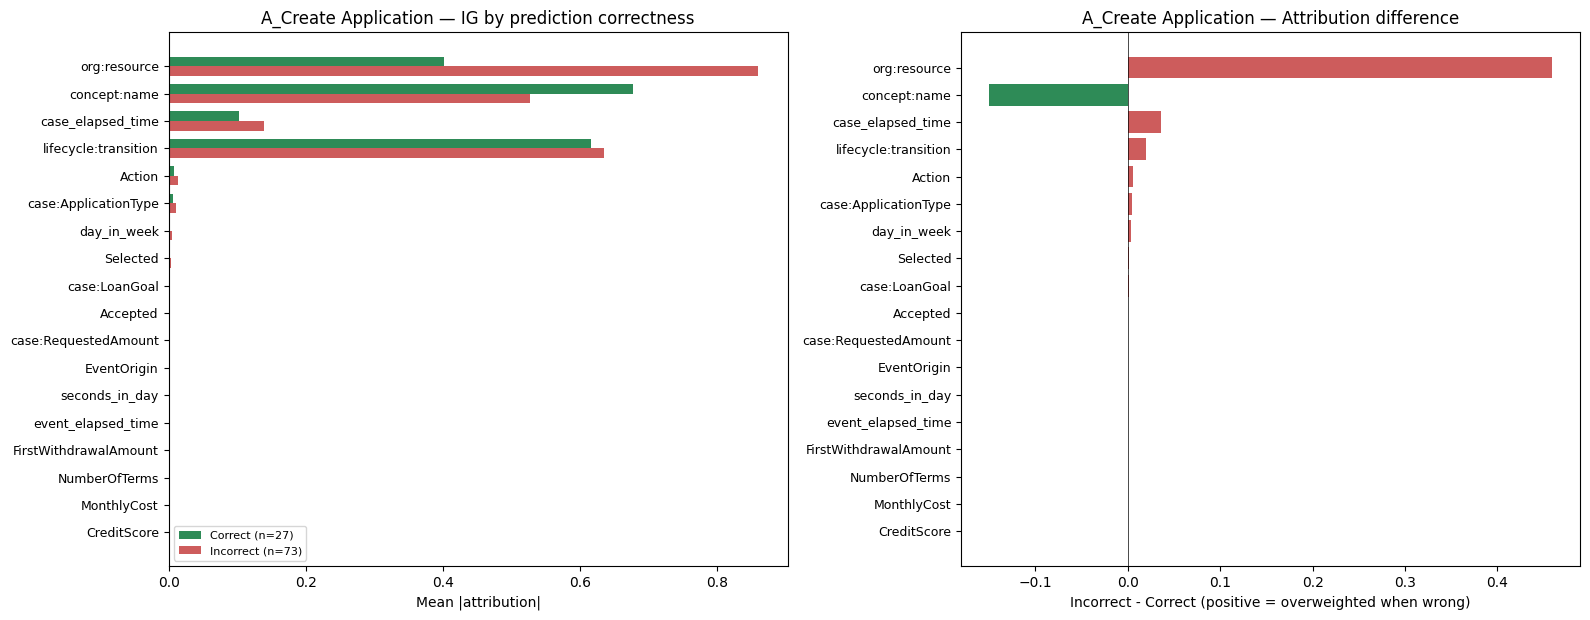

  Overweighted when wrong: org:resource (+0.4589), case_elapsed_time (+0.0354), lifecycle:transition (+0.0196)
  Underweighted when wrong: concept:name (-0.1500), seconds_in_day (-0.0000)


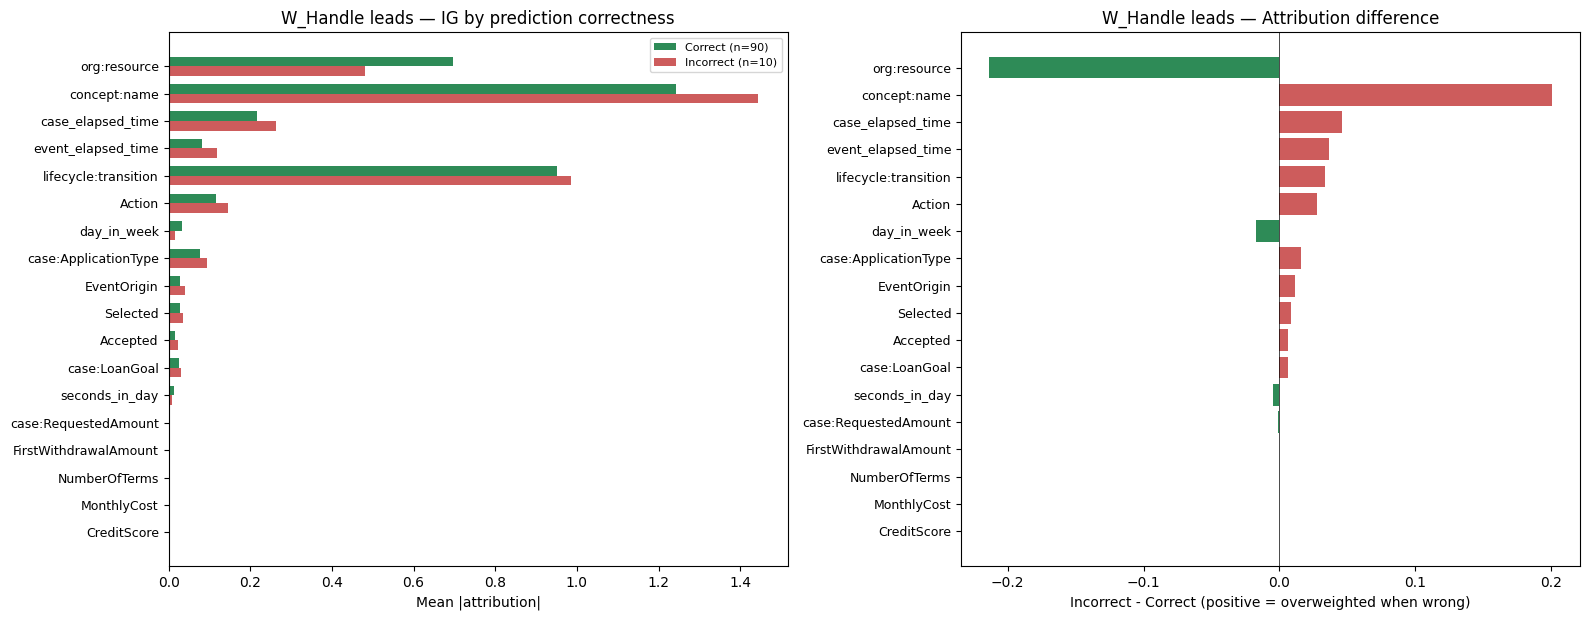

  Overweighted when wrong: concept:name (+0.2005), case_elapsed_time (+0.0459), event_elapsed_time (+0.0367)
  Underweighted when wrong: org:resource (-0.2137), day_in_week (-0.0170), seconds_in_day (-0.0049)


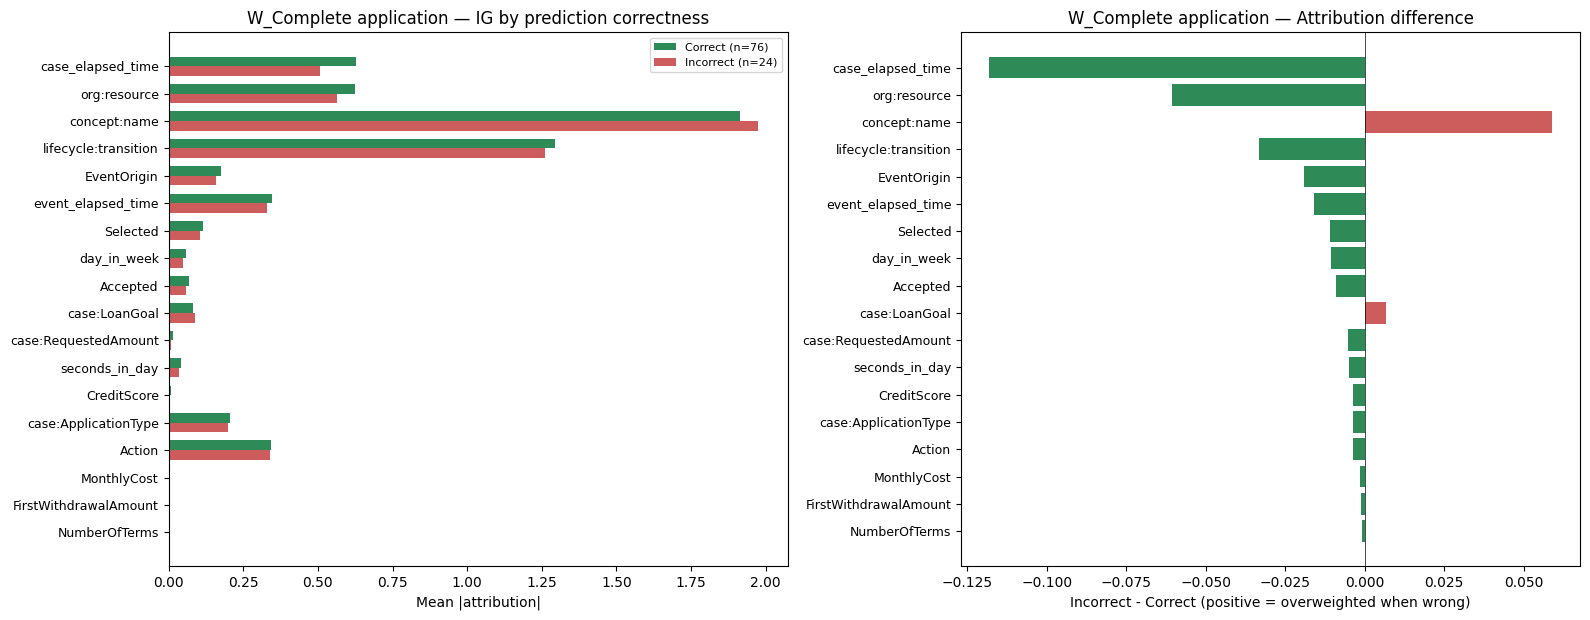

  Overweighted when wrong: concept:name (+0.0589), case:LoanGoal (+0.0066)
  Underweighted when wrong: case_elapsed_time (-0.1181), org:resource (-0.0607), lifecycle:transition (-0.0332)


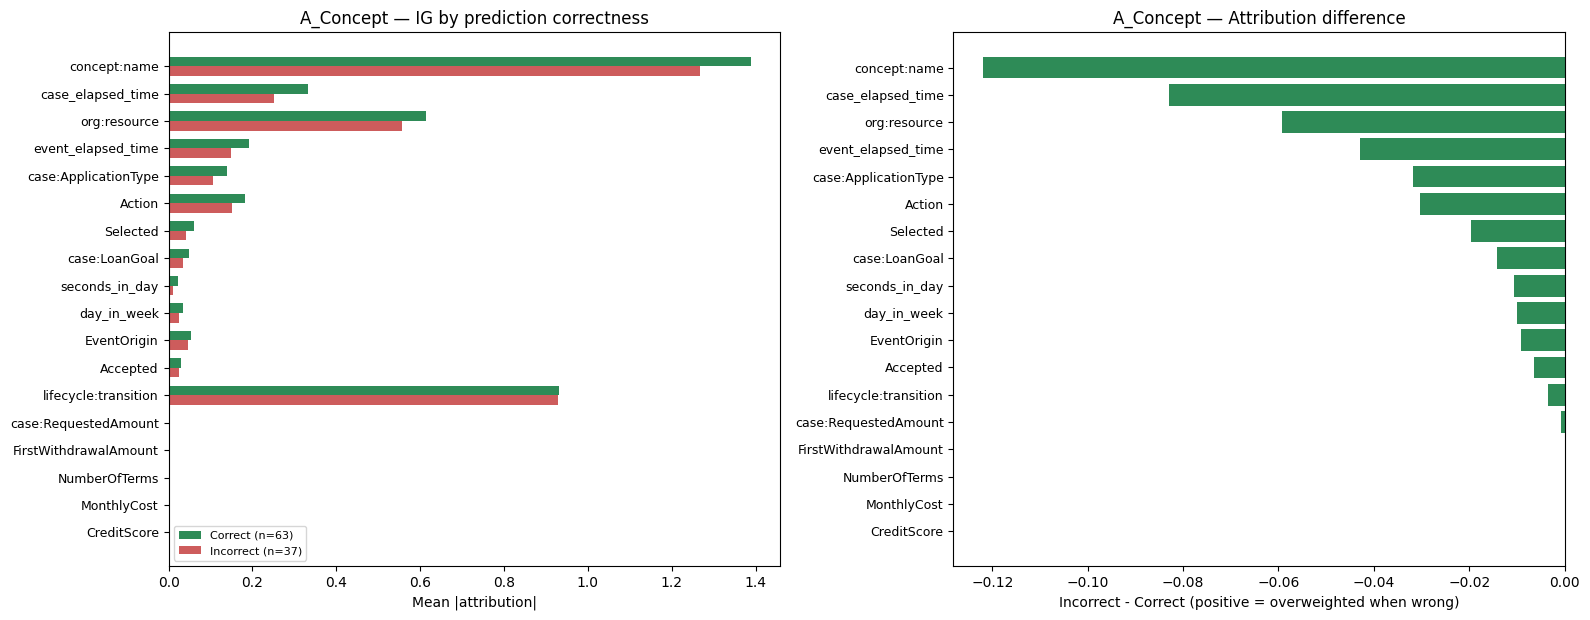

  Underweighted when wrong: concept:name (-0.1220), case_elapsed_time (-0.0830), org:resource (-0.0592)


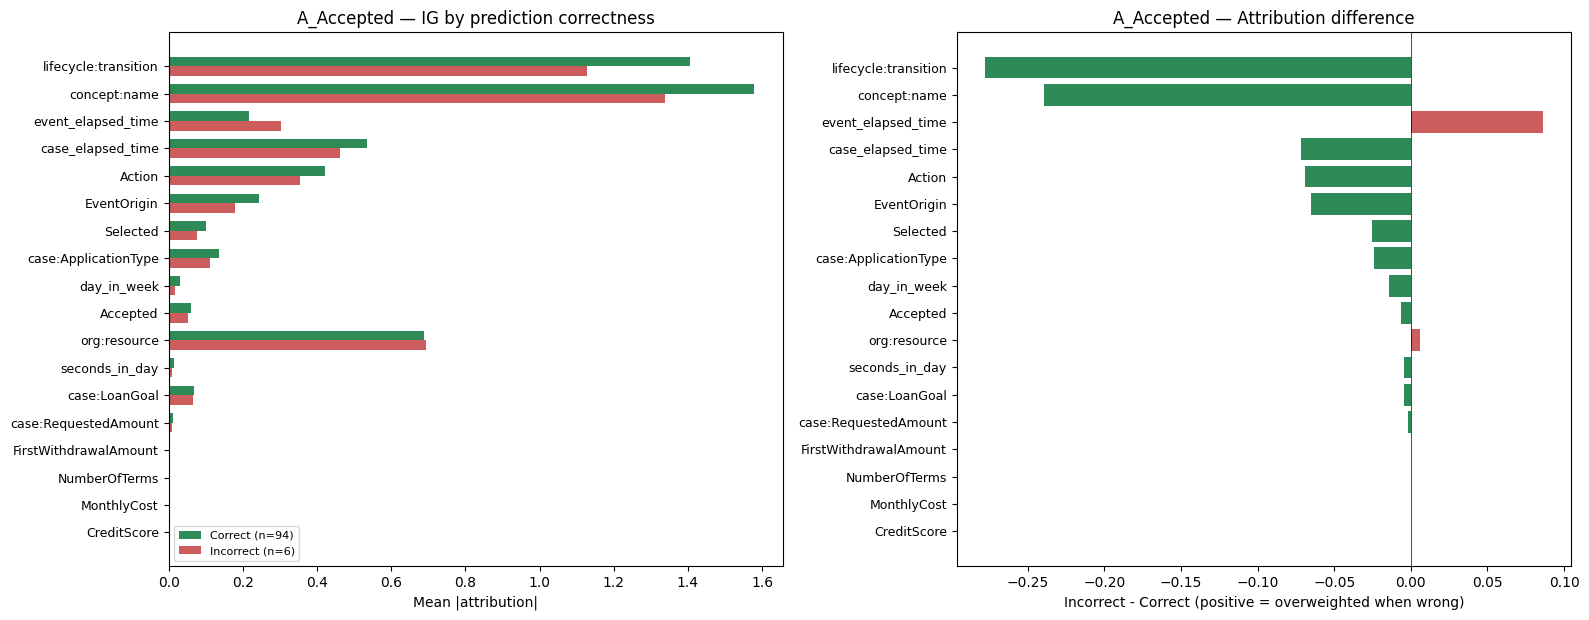

  Overweighted when wrong: event_elapsed_time (+0.0865), org:resource (+0.0059)
  Underweighted when wrong: lifecycle:transition (-0.2781), concept:name (-0.2393), case_elapsed_time (-0.0719)


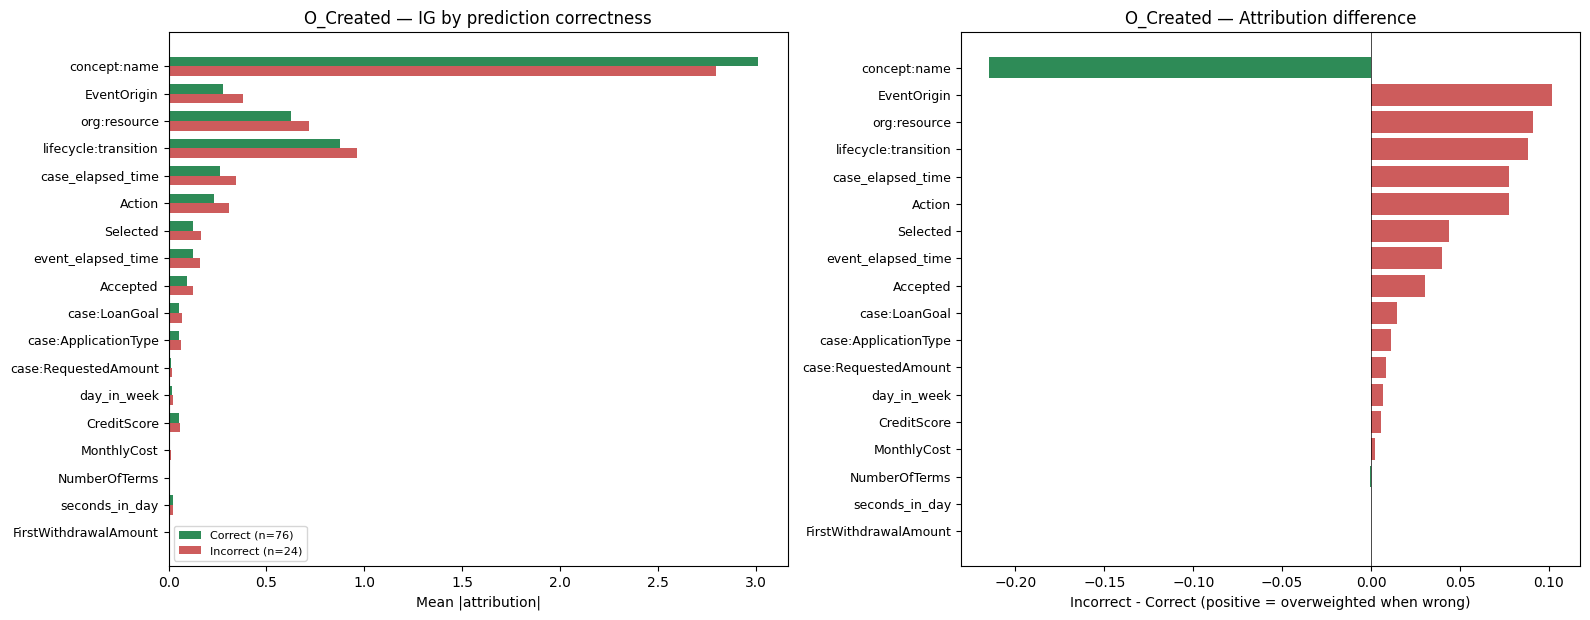

  Overweighted when wrong: EventOrigin (+0.1017), org:resource (+0.0910), lifecycle:transition (+0.0881)
  Underweighted when wrong: concept:name (-0.2147), NumberOfTerms (-0.0004), seconds_in_day (-0.0002)


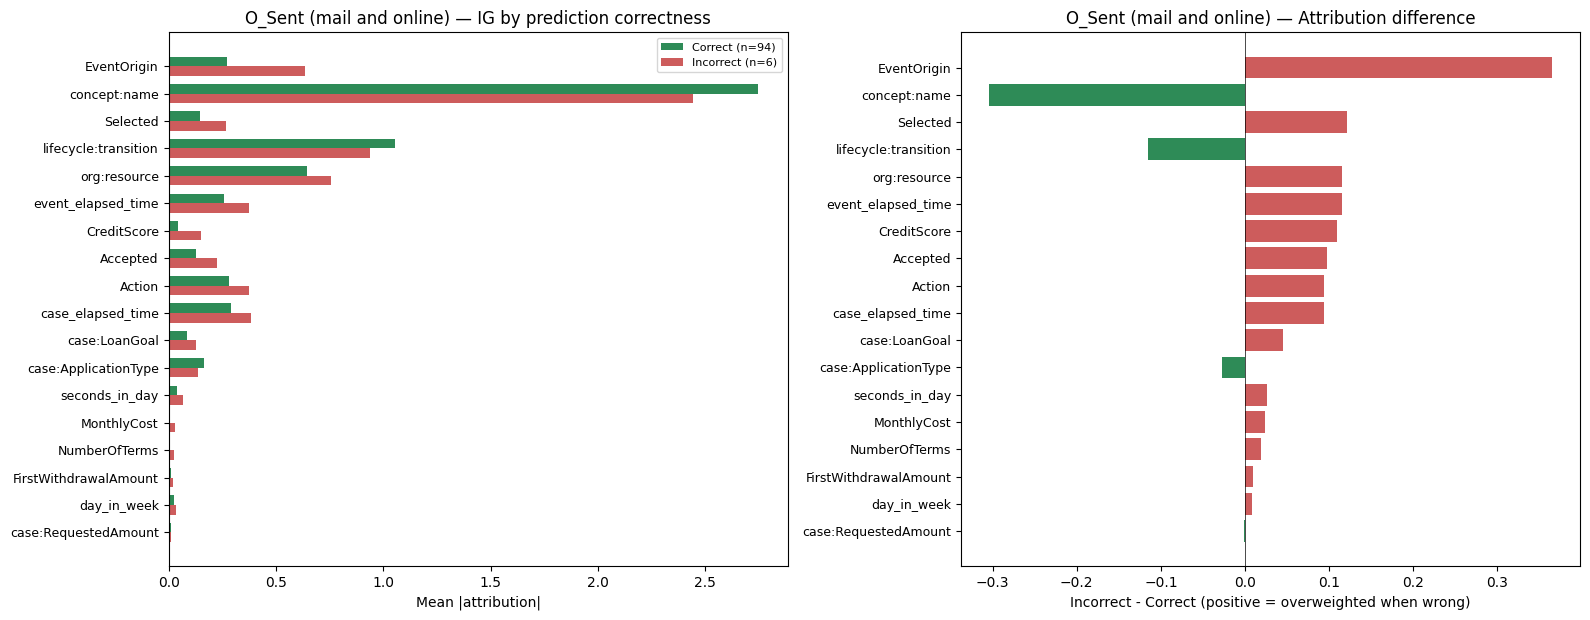

  Overweighted when wrong: EventOrigin (+0.3647), Selected (+0.1208), org:resource (+0.1151)
  Underweighted when wrong: concept:name (-0.3040), lifecycle:transition (-0.1157), case:ApplicationType (-0.0272)


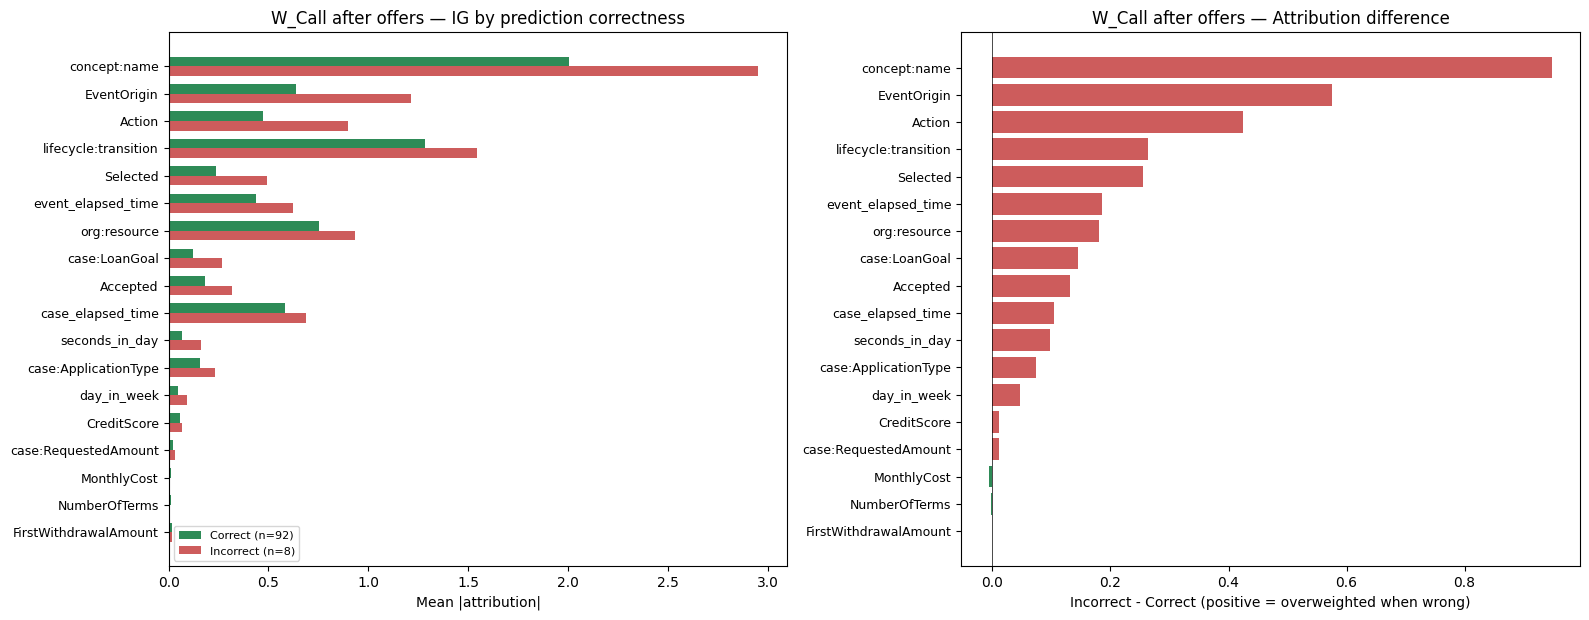

  Overweighted when wrong: concept:name (+0.9479), EventOrigin (+0.5760), Action (+0.4254)
  Underweighted when wrong: MonthlyCost (-0.0054), NumberOfTerms (-0.0031), FirstWithdrawalAmount (-0.0002)


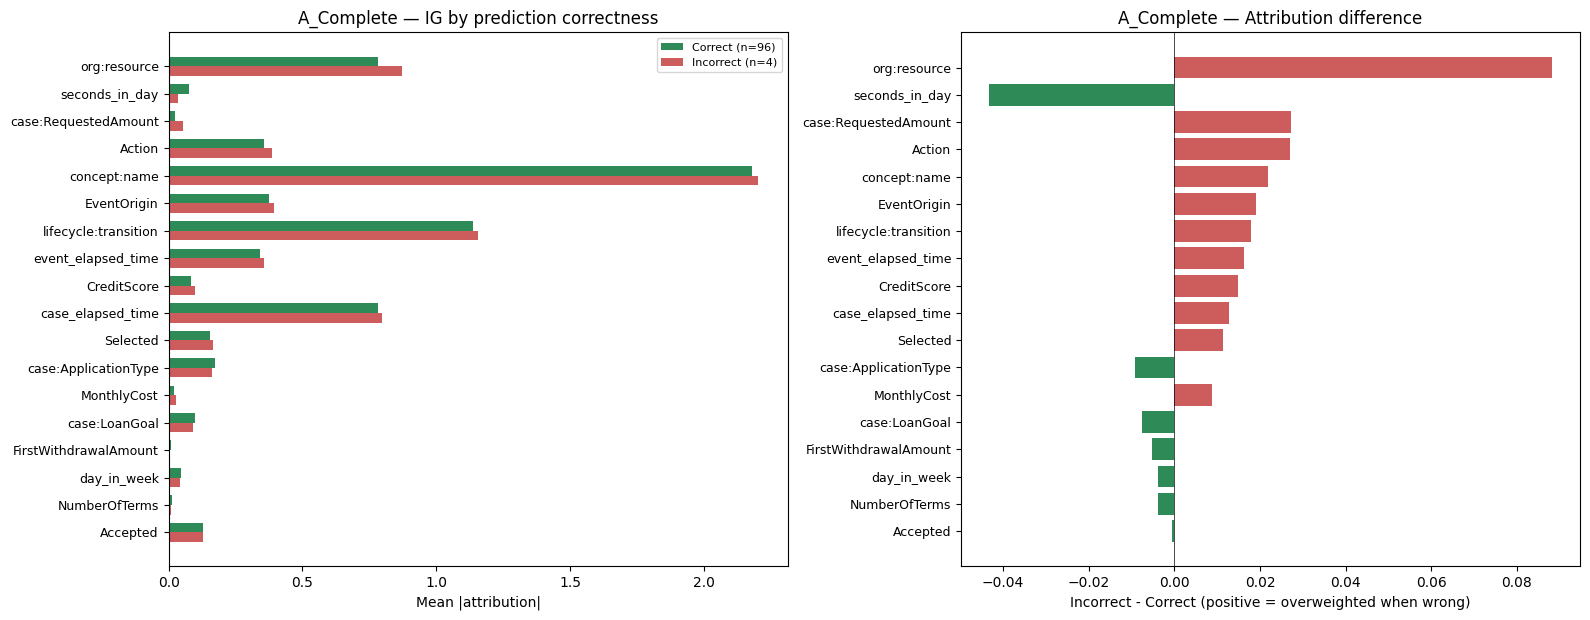

  Overweighted when wrong: org:resource (+0.0881), case:RequestedAmount (+0.0273), Action (+0.0269)
  Underweighted when wrong: seconds_in_day (-0.0432), case:ApplicationType (-0.0093), case:LoanGoal (-0.0076)


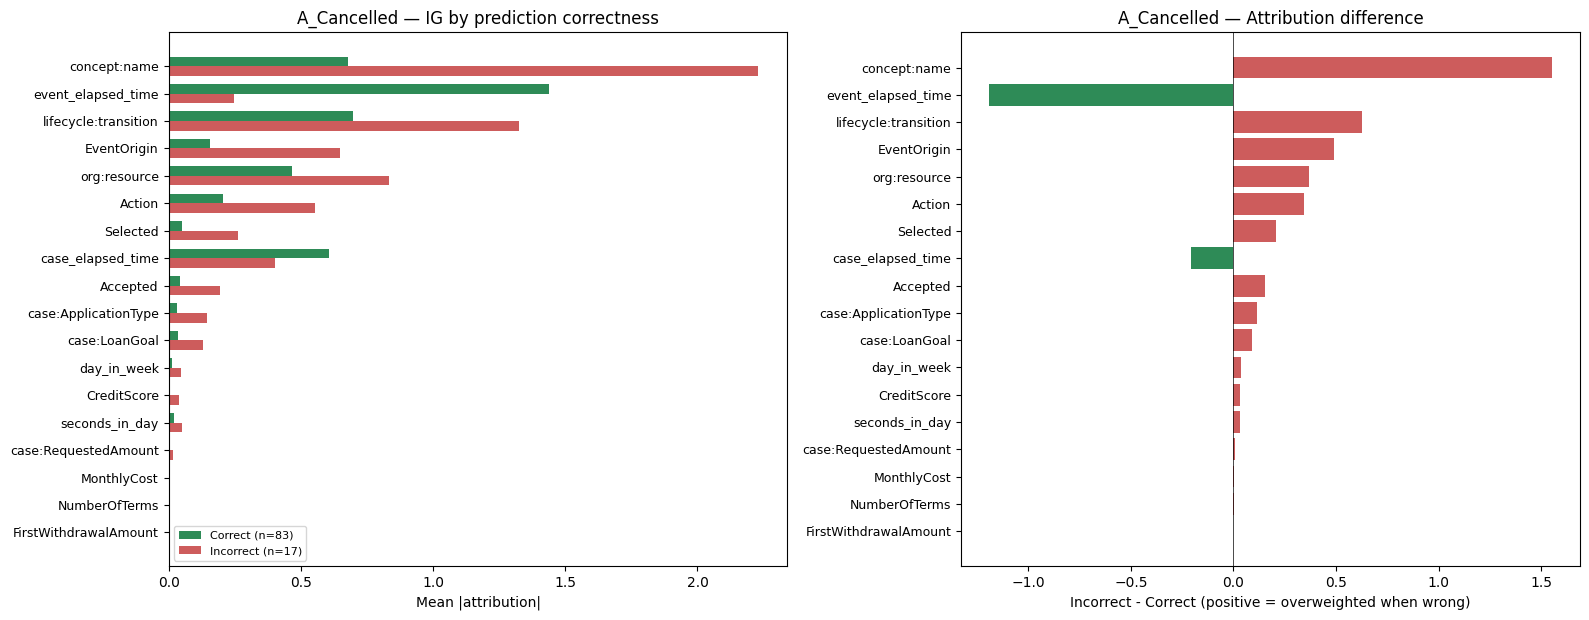

  Overweighted when wrong: concept:name (+1.5521), lifecycle:transition (+0.6288), EventOrigin (+0.4918)
  Underweighted when wrong: event_elapsed_time (-1.1900), case_elapsed_time (-0.2074)


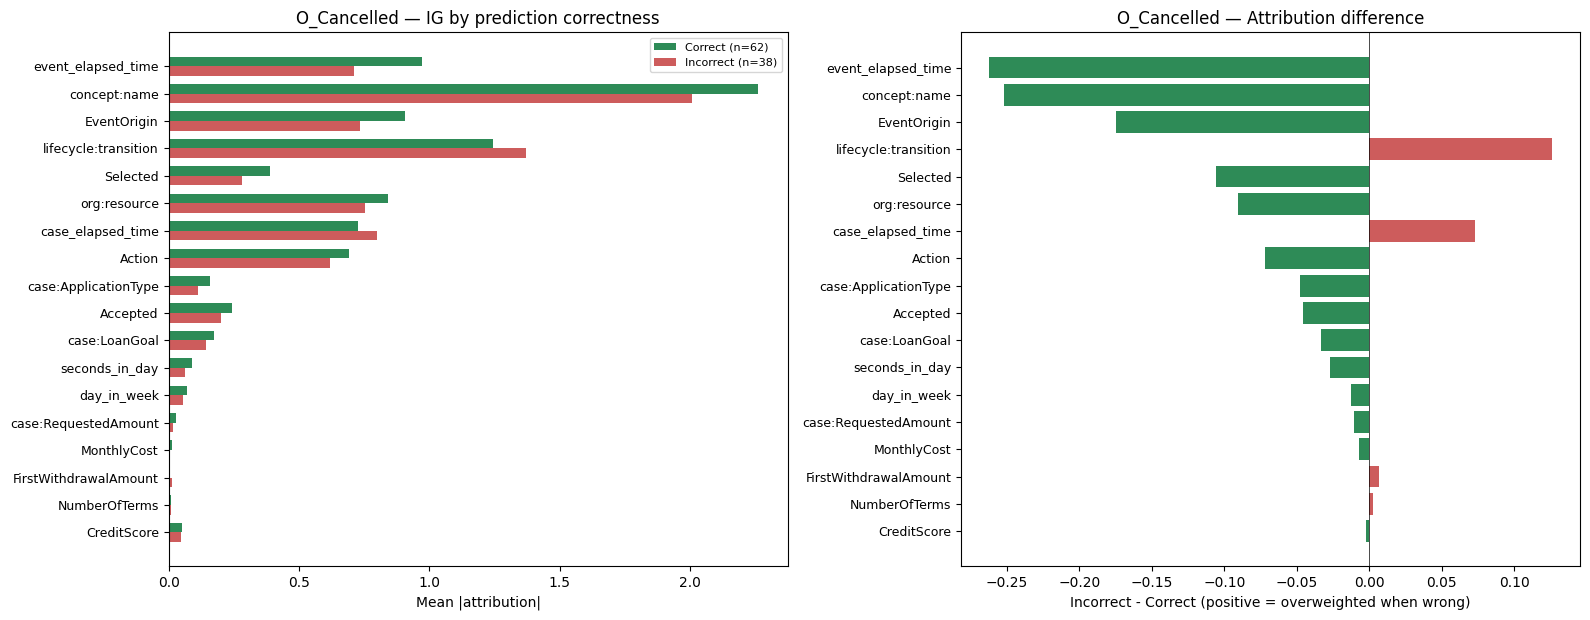

  Overweighted when wrong: lifecycle:transition (+0.1261), case_elapsed_time (+0.0730), FirstWithdrawalAmount (+0.0071)
  Underweighted when wrong: event_elapsed_time (-0.2623), concept:name (-0.2523), EventOrigin (-0.1746)


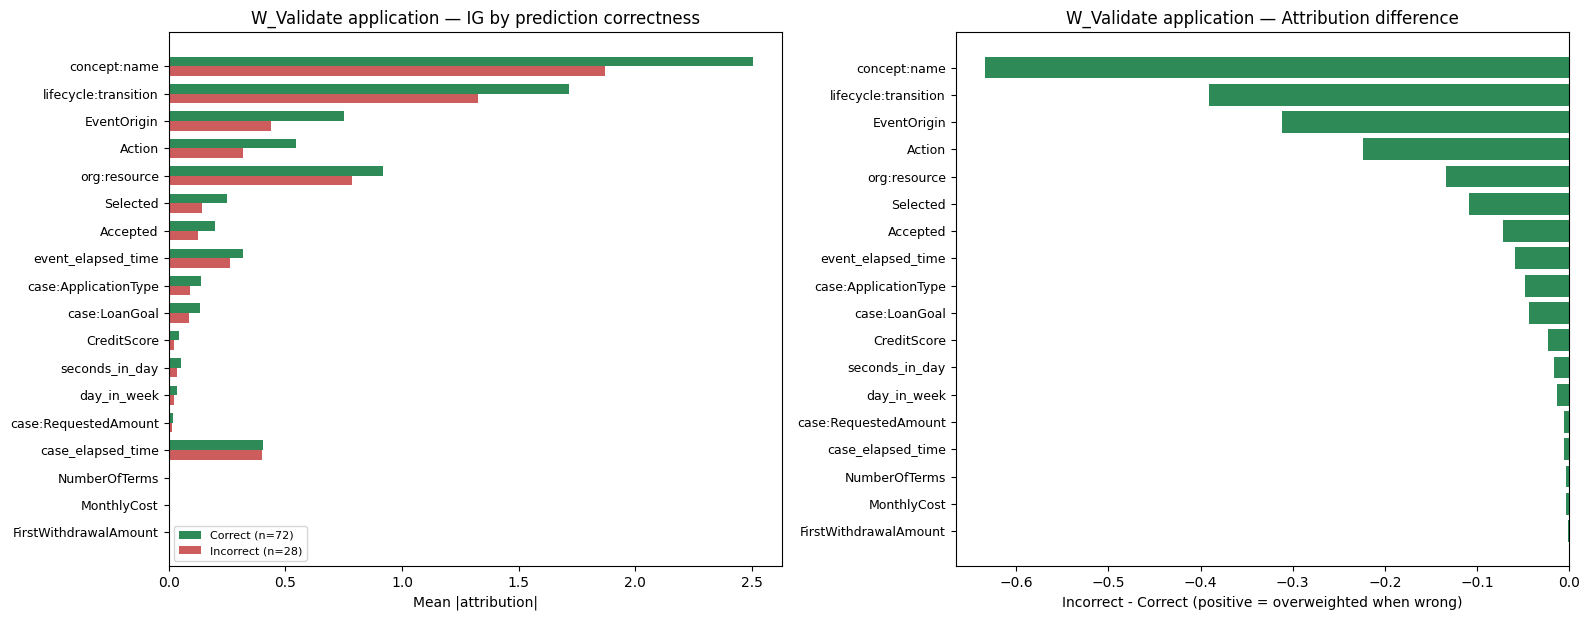

  Underweighted when wrong: concept:name (-0.6341), lifecycle:transition (-0.3905), EventOrigin (-0.3111)


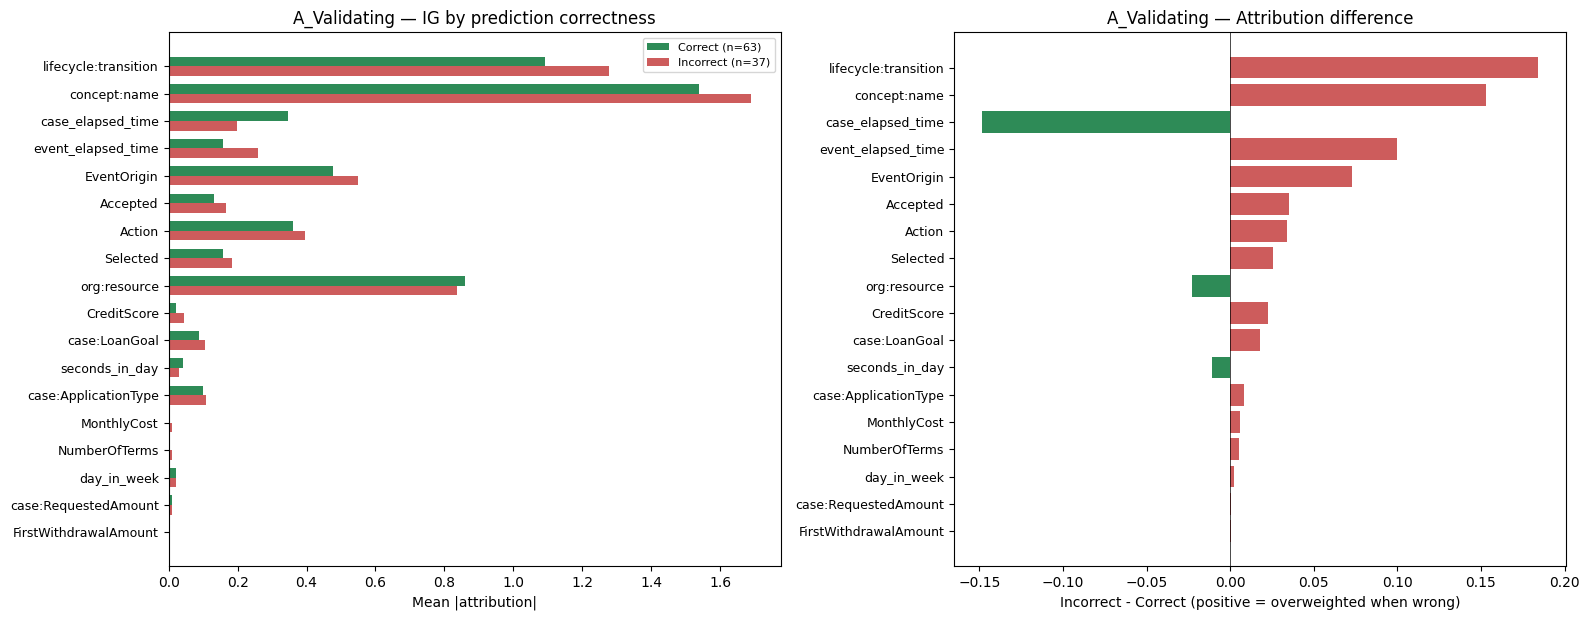

  Overweighted when wrong: lifecycle:transition (+0.1843), concept:name (+0.1530), event_elapsed_time (+0.0999)
  Underweighted when wrong: case_elapsed_time (-0.1485), org:resource (-0.0228), seconds_in_day (-0.0109)


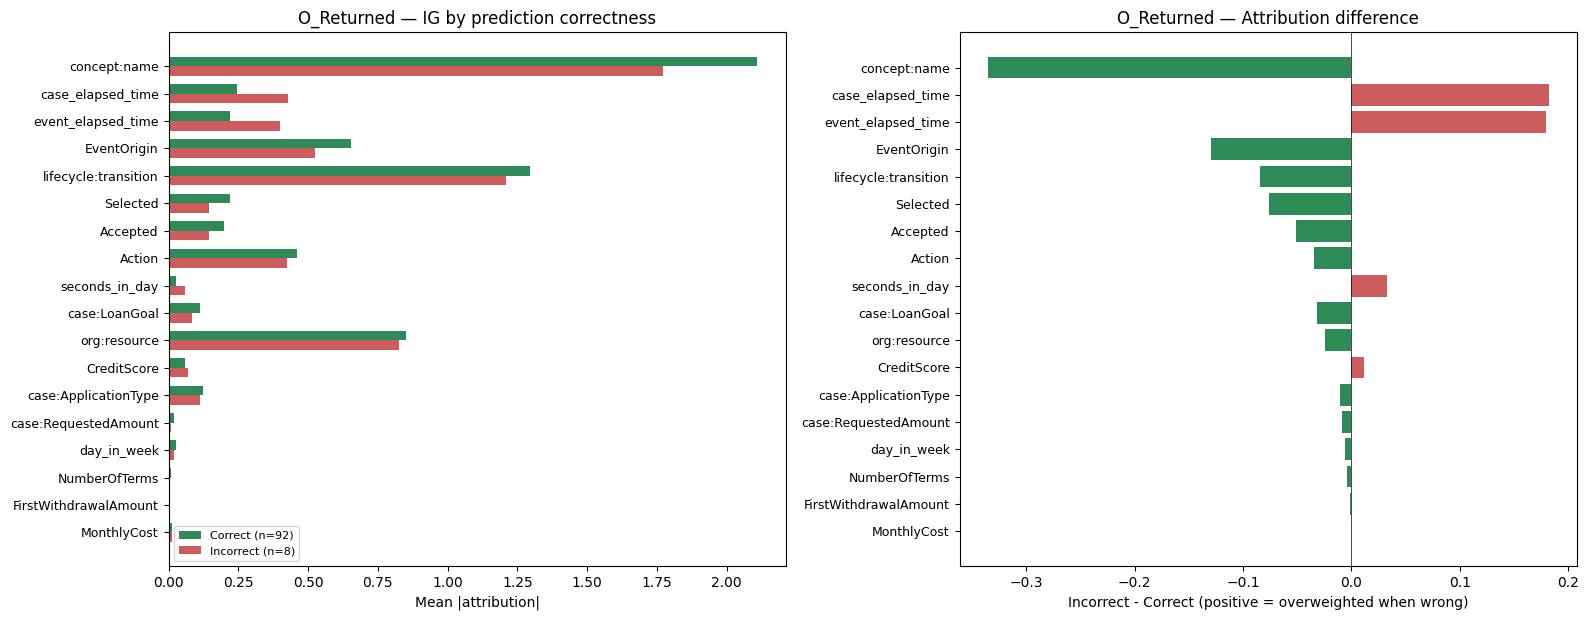

  Overweighted when wrong: case_elapsed_time (+0.1820), event_elapsed_time (+0.1792), seconds_in_day (+0.0327)
  Underweighted when wrong: concept:name (-0.3355), EventOrigin (-0.1298), lifecycle:transition (-0.0848)


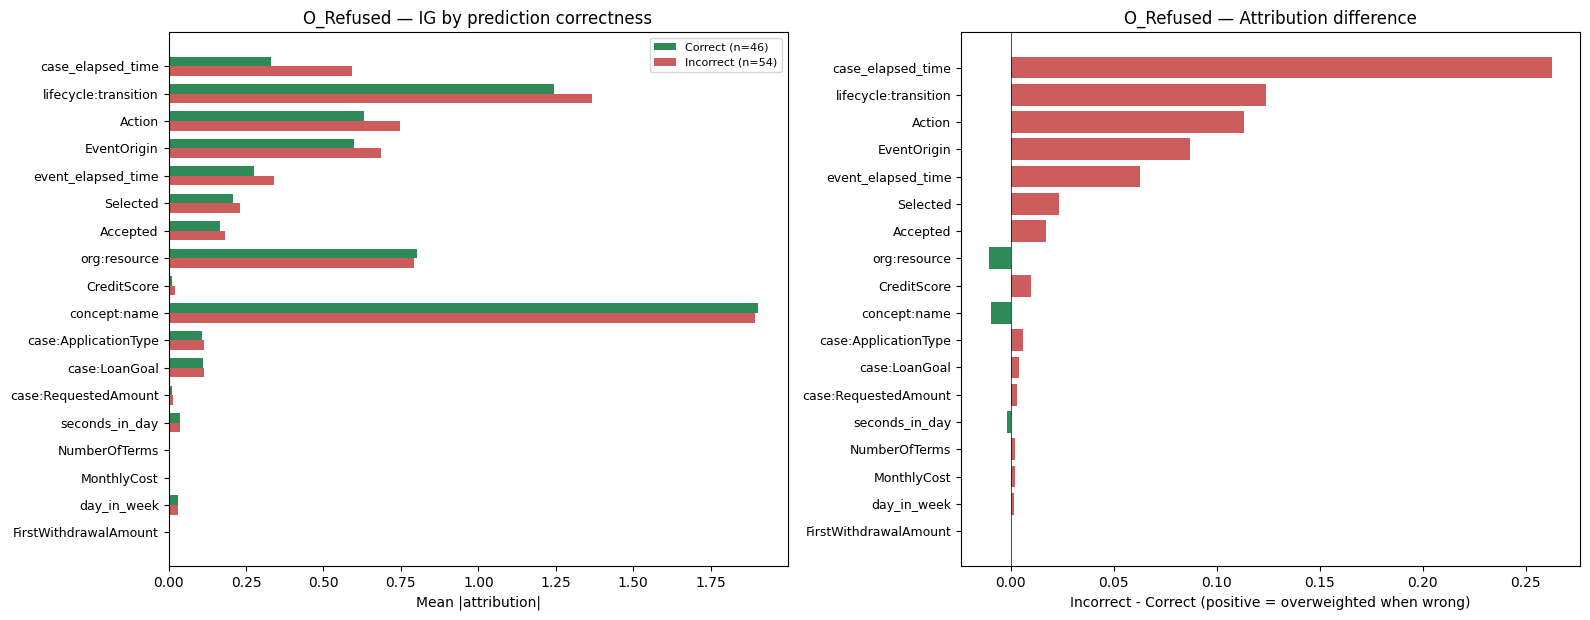

  Overweighted when wrong: case_elapsed_time (+0.2628), lifecycle:transition (+0.1239), Action (+0.1135)
  Underweighted when wrong: org:resource (-0.0105), concept:name (-0.0097), seconds_in_day (-0.0020)


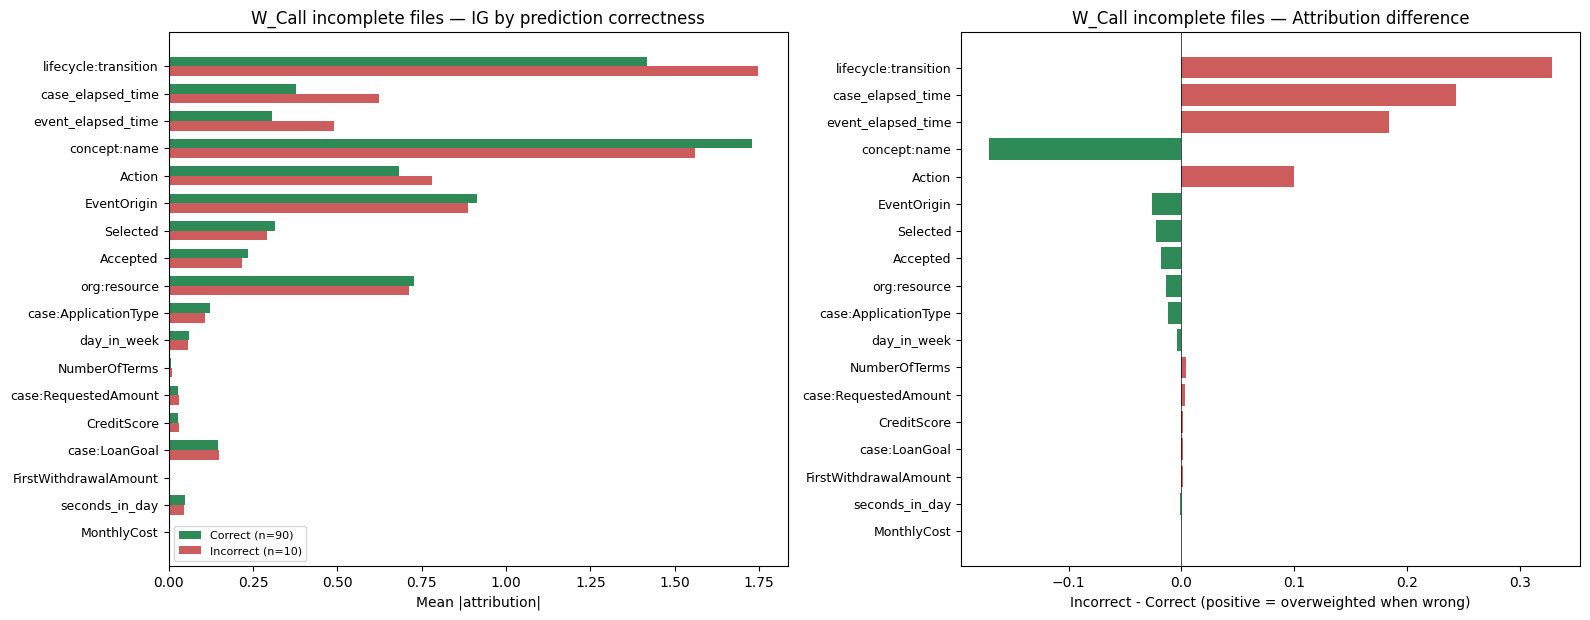

  Overweighted when wrong: lifecycle:transition (+0.3283), case_elapsed_time (+0.2436), event_elapsed_time (+0.1840)
  Underweighted when wrong: concept:name (-0.1703), EventOrigin (-0.0262), Selected (-0.0224)


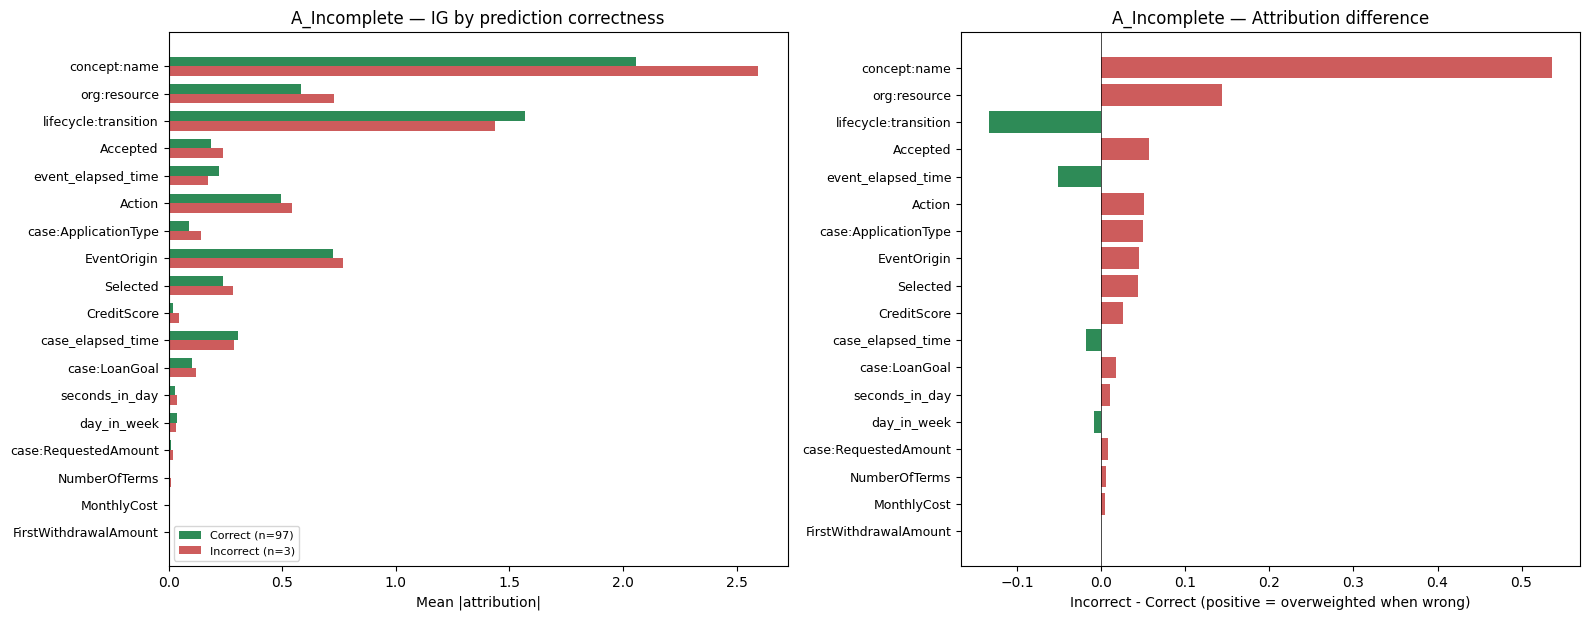

  Overweighted when wrong: concept:name (+0.5361), org:resource (+0.1435), Accepted (+0.0562)
  Underweighted when wrong: lifecycle:transition (-0.1333), event_elapsed_time (-0.0519), case_elapsed_time (-0.0186)


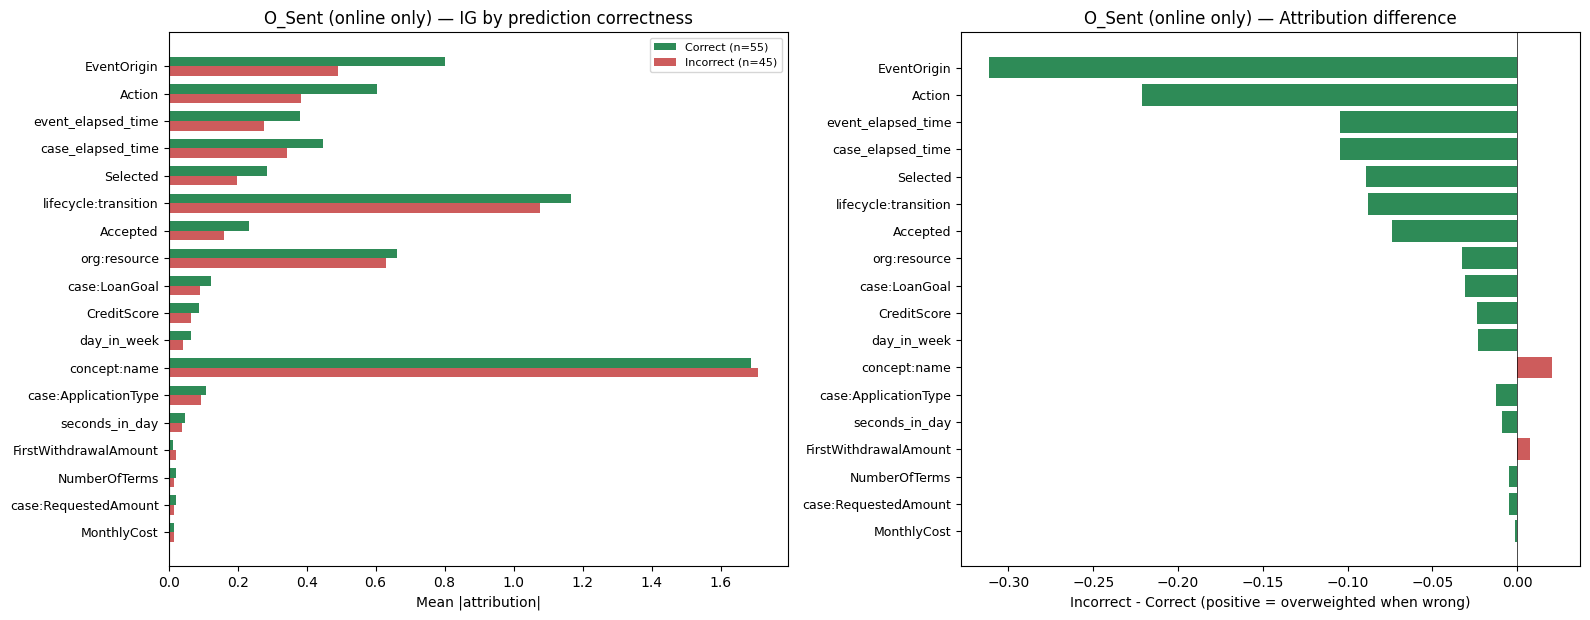

  Overweighted when wrong: concept:name (+0.0205), FirstWithdrawalAmount (+0.0077)
  Underweighted when wrong: EventOrigin (-0.3113), Action (-0.2211), event_elapsed_time (-0.1046)


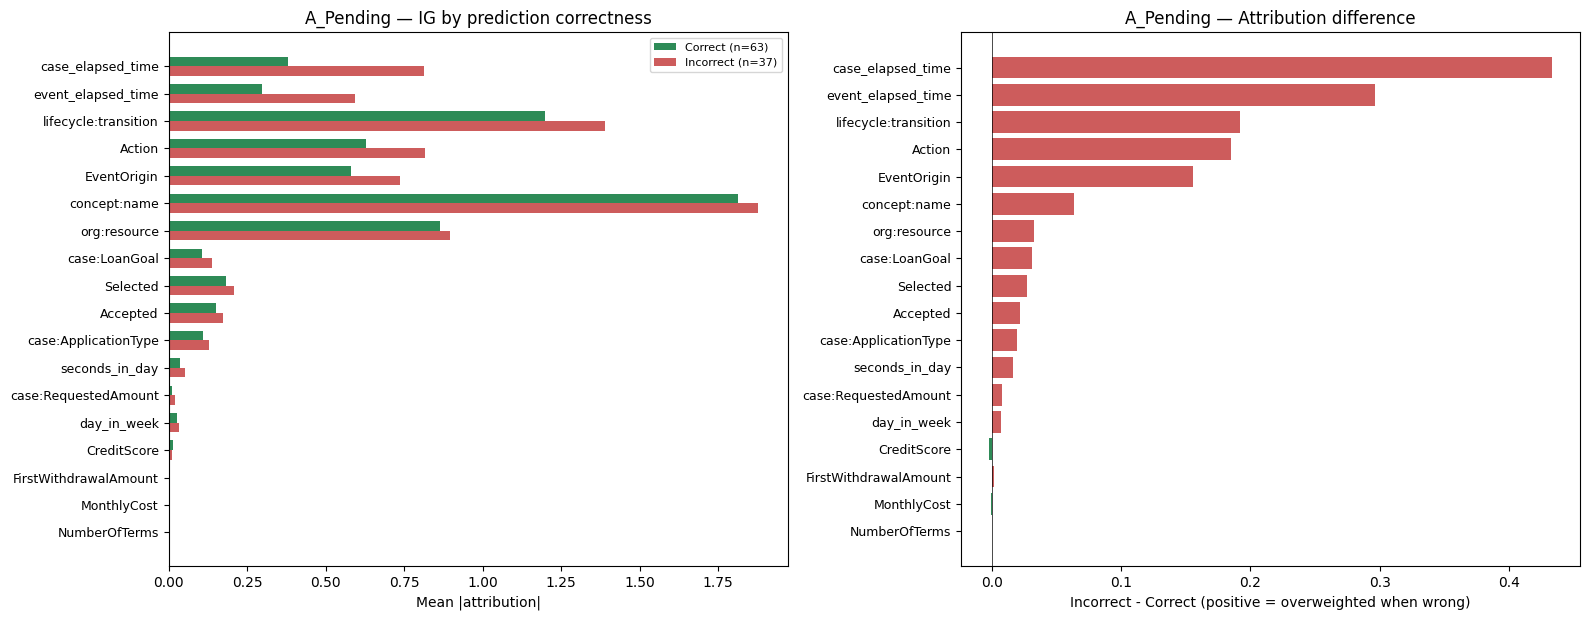

  Overweighted when wrong: case_elapsed_time (+0.4333), event_elapsed_time (+0.2960), lifecycle:transition (+0.1922)
  Underweighted when wrong: CreditScore (-0.0022), MonthlyCost (-0.0008)


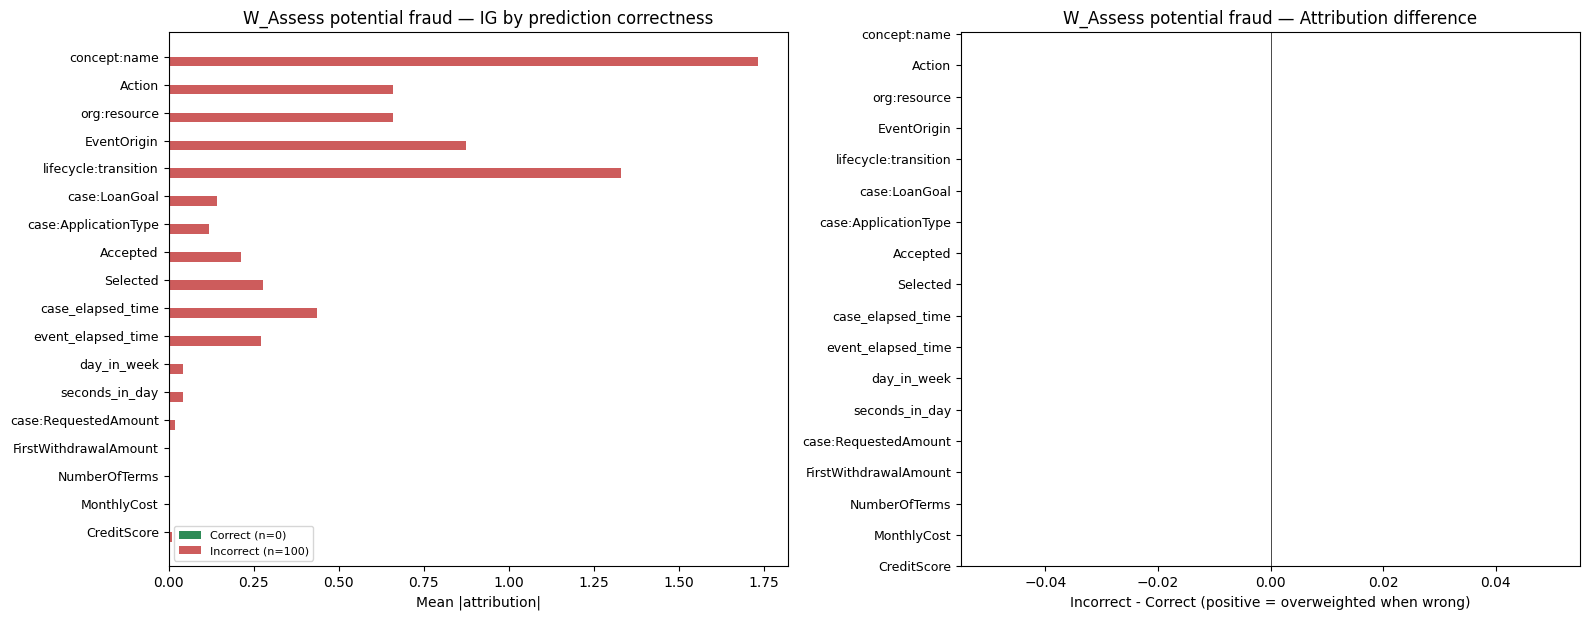

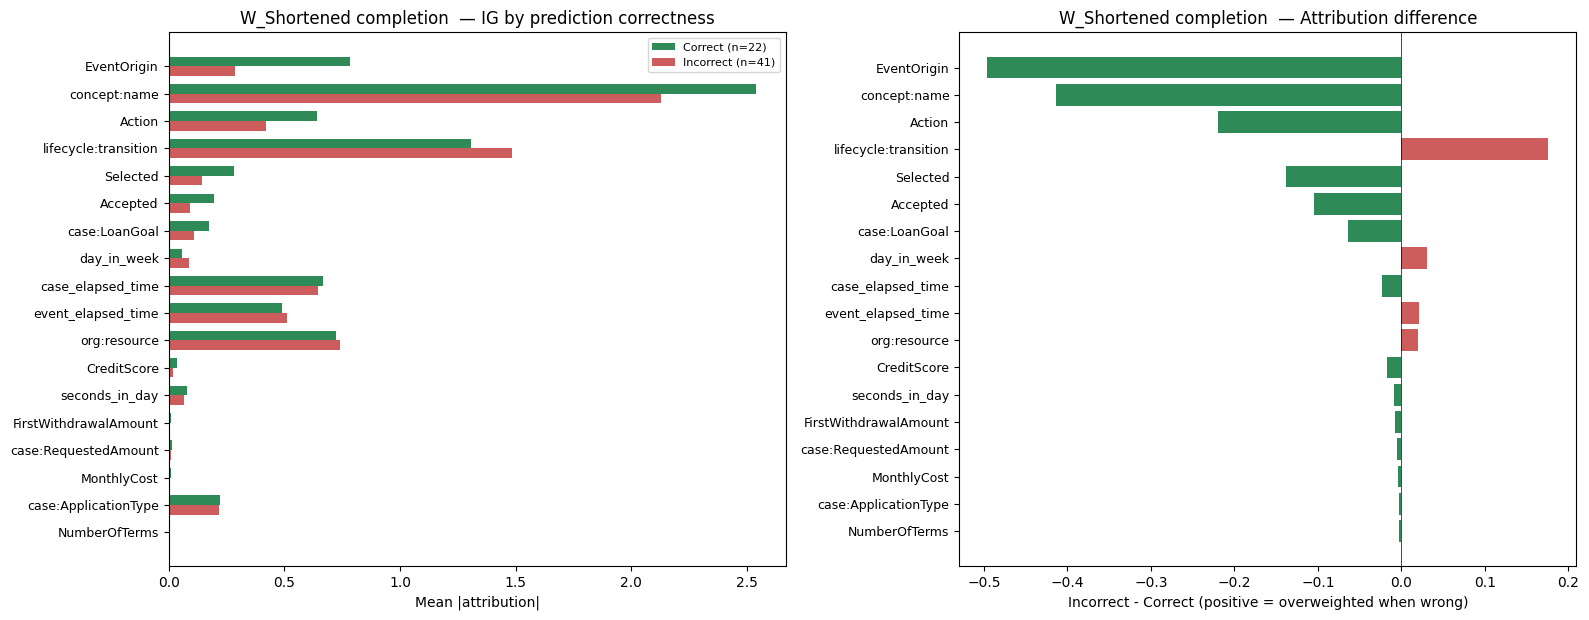

  Overweighted when wrong: lifecycle:transition (+0.1759), day_in_week (+0.0306), event_elapsed_time (+0.0214)
  Underweighted when wrong: EventOrigin (-0.4960), concept:name (-0.4139), Action (-0.2194)


In [7]:
for gateway_act in ig_results:
    ig_df = ig_results[gateway_act]
    ig_features = [f for f in ALL_FEATURES if f in ig_df.columns]

    correct = ig_df[ig_df['y_lstm'] == ig_df['y_actual']]
    incorrect = ig_df[ig_df['y_lstm'] != ig_df['y_actual']]

    if len(incorrect) < 3:
        print(f'{gateway_act}: only {len(incorrect)} incorrect predictions, skipping')
        continue

    mean_correct = correct[ig_features].mean()
    mean_incorrect = incorrect[ig_features].mean()

    diff = mean_incorrect - mean_correct
    order = diff.abs().sort_values(ascending=False).index
    mean_correct = mean_correct[order]
    mean_incorrect = mean_incorrect[order]
    diff = diff[order]

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(ig_features) * 0.35)))

    y_pos = np.arange(len(order))
    bar_h = 0.35
    ax = axes[0]
    ax.barh(y_pos - bar_h / 2, mean_correct.values, bar_h,
            label=f'Correct (n={len(correct)})', color='seagreen')
    ax.barh(y_pos + bar_h / 2, mean_incorrect.values, bar_h,
            label=f'Incorrect (n={len(incorrect)})', color='indianred')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(order, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Mean |attribution|')
    ax.set_title(f'{gateway_act} — IG by prediction correctness')
    ax.legend(fontsize=8)

    ax = axes[1]
    colors = ['indianred' if d > 0 else 'seagreen' for d in diff.values]
    ax.barh(y_pos, diff.values, color=colors)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(order, fontsize=9)
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Incorrect - Correct (positive = overweighted when wrong)')
    ax.set_title(f'{gateway_act} — Attribution difference')

    plt.tight_layout()
    plt.show()

    top_over = diff[diff > 0].head(3)
    top_under = diff[diff < 0].head(3)
    if len(top_over) > 0:
        print(f'  Overweighted when wrong: {", ".join(f"{f} (+{v:.4f})" for f, v in top_over.items())}')
    if len(top_under) > 0:
        print(f'  Underweighted when wrong: {", ".join(f"{f} ({v:.4f})" for f, v in top_under.items())}')